# 03 — Data Cleaning

**Input:** view `public.vw_city_temperature_enriched` được bàn giao từ `02_postgresql_pipeline.ipynb`.

**Output:** bảng `public.cleaned_city_temperature` trong PostgreSQL và file `data/processed/cleaned_city_temperature.csv`.

Notebook này làm sạch bảng chính City ở grain **một thành phố tại một tháng**. View đầu vào dùng trực tiếp các giá trị nghiệp vụ, không xuất các cột ID; mỗi dòng được định danh bằng khóa nghiệp vụ `observation_date + city_name + country_name + latitude + longitude`.


## 1. Mục tiêu, vai trò và pipeline làm sạch

### 1.1. Mục tiêu của Notebook

Notebook 03 biến dữ liệu đã được tích hợp trong PostgreSQL thành một tập dữ liệu sạch, nhất quán và sẵn sàng cho EDA. Các công việc chính gồm:

- Sử dụng `city_average_temperature` làm biến nhiệt độ City chính (target cho các bước mô hình sau);
- Đánh giá chất lượng dữ liệu trước khi xử lý;
- Chuẩn hóa kiểu dữ liệu, ngày tháng và giá trị văn bản;
- Xử lý missing values và duplicate theo quy tắc có giải thích;
- Kiểm tra giá trị sai miền, tính nhất quán nghiệp vụ và outlier;
- So sánh chất lượng trước–sau;
- Lưu kết quả vào PostgreSQL và `data/processed/` để Notebook 04 sử dụng.

### 1.2. Vai trò của Data Cleaning trong dự án

Notebook 01 đã xác định City là bảng chính. Notebook 02 đã giới hạn dữ liệu City còn **50 quốc gia có nhiều bản ghi nhất** trong giai đoạn 1863–2013, chuẩn hóa mô hình dimension/fact và tạo view hợp nhất gồm các giá trị nghiệp vụ trực tiếp. Notebook 03 không quay lại đọc CSV và không lặp lại công việc tích hợp dữ liệu; nhiệm vụ ở đây là xử lý các vấn đề chất lượng còn tồn tại trong view bàn giao.

```text
PostgreSQL: vw_city_temperature_enriched
                    ↓
          Data Quality Assessment
                    ↓
 Missing → Duplicate → Invalid/Logic → Outlier
                    ↓
       Data Type & Text Standardization
                    ↓
 PostgreSQL: cleaned_city_temperature + CSV
                    ↓
          Notebook 04 — EDA
```


## 2. Chuẩn bị môi trường và kết nối PostgreSQL

### 2.1. Nạp các thư viện cần thiết

`pandas` và `numpy` phục vụ xử lý dữ liệu; `SQLAlchemy` kết hợp `psycopg2` dùng để đọc và ghi PostgreSQL; `python-dotenv` nạp cấu hình từ `.env` mà không ghi mật khẩu vào notebook.

In [3]:
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv
from IPython.display import display
from sqlalchemy import URL, create_engine, text

pd.set_option('display.max_columns', 40)
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.float_format', lambda value: f'{value:,.4f}')
warnings.filterwarnings('ignore', category=FutureWarning)

### 2.2. Xác định thư mục dự án và đầu ra

Notebook có thể được mở từ thư mục gốc, `notebooks_v1/` hoặc `notebooks_v2/`. Hàm dưới tìm project root dựa trên hai thư mục ổn định `data/` và `SQL/`, sau đó chuẩn bị `data/processed/` cho file kết quả.

In [4]:
def find_project_root(start: Path) -> Path:
    """Tìm thư mục gốc chứa cả data/ và SQL/."""
    for candidate in (start, *start.parents):
        if (candidate / 'data').is_dir() and (candidate / 'SQL').is_dir():
            return candidate
    raise FileNotFoundError('Không tìm thấy project root chứa data/ và SQL/.')


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

CLEANED_CSV_PATH = PROCESSED_DIR / 'cleaned_city_temperature.csv'
SOURCE_VIEW = 'vw_city_temperature_enriched'
CLEANED_TABLE = 'cleaned_city_temperature'

print('Project root :', PROJECT_ROOT)
print('Output CSV   :', CLEANED_CSV_PATH)

Project root : E:\FPT\HocKy3\PROJECT_1\PROJECT\Global-Surface-Temperature-Analysis
Output CSV   : E:\FPT\HocKy3\PROJECT_1\PROJECT\Global-Surface-Temperature-Analysis\data\processed\cleaned_city_temperature.csv


Đường dẫn in ra phải trỏ tới đúng project hiện tại. Notebook chỉ tạo thư mục đầu ra nếu chưa tồn tại; không đọc, ghi hoặc thay đổi các file trong `data/raw/`.

### 2.3. Đọc cấu hình và kiểm tra kết nối

Tạo file `.env` ở project root với nội dung tương tự:

```text
DB_HOST=localhost
DB_PORT=5432
DB_NAME=climate_db
DB_USER=postgres
DB_PASSWORD=<mật khẩu PostgreSQL trên máy đang chạy>
```

Code chỉ kiểm tra sự tồn tại của biến, kết nối tới `climate_db` và xác nhận view bàn giao; mật khẩu không được hiển thị.

In [5]:
ENV_PATH = PROJECT_ROOT / '.env'
if not ENV_PATH.is_file():
    raise FileNotFoundError(
        'Không tìm thấy .env. Hãy tạo file này từ .env.example và điền cấu hình PostgreSQL.'
    )

load_dotenv(ENV_PATH, override=False)
required_env = ('DB_HOST', 'DB_PORT', 'DB_NAME', 'DB_USER', 'DB_PASSWORD')
missing_env = [name for name in required_env if not os.getenv(name)]
if missing_env:
    raise EnvironmentError(f'.env thiếu các biến: {missing_env}')

DB_CONFIG = {
    'host': os.environ['DB_HOST'],
    'port': int(os.environ['DB_PORT']),
    'dbname': os.environ['DB_NAME'],
    'user': os.environ['DB_USER'],
    'password': os.environ['DB_PASSWORD'],
    'connect_timeout': 10,
}

database_url = URL.create(
    drivername='postgresql+psycopg2',
    username=DB_CONFIG['user'],
    password=DB_CONFIG['password'],
    host=DB_CONFIG['host'],
    port=DB_CONFIG['port'],
    database=DB_CONFIG['dbname'],
)
engine = create_engine(database_url, pool_pre_ping=True)

connection_check_sql = text("""
SELECT
    current_database() AS database_name,
    current_user AS database_user,
    version() AS postgresql_version,
    to_regclass('public.vw_city_temperature_enriched') IS NOT NULL AS source_view_exists;
""")

with engine.connect() as connection:
    connection_check = pd.read_sql_query(connection_check_sql, connection)

display(connection_check)
if connection_check.loc[0, 'database_name'] != 'climate_db':
    raise RuntimeError('Notebook phải kết nối database climate_db.')
if not bool(connection_check.loc[0, 'source_view_exists']):
    raise RuntimeError(f'Không tìm thấy public.{SOURCE_VIEW}. Hãy hoàn thành Notebook 02 trước.')

,database_name,database_user,postgresql_version,source_view_exists
0,climate_db,postgres,"PostgreSQL 18.3 on x86_64-windows, compiled by msvc-19.44.35223, 64-bit",True


Kết quả hợp lệ phải cho thấy `database_name = climate_db` và `source_view_exists = True`. Nếu không đạt, cần kiểm tra lại file `.env`, PostgreSQL service hoặc quá trình restore/chạy Notebook 02 trước khi tiếp tục.

## 3. Đọc dữ liệu từ PostgreSQL

### 3.1. Xác nhận data contract của nguồn

Theo Notebook 02, view nguồn phải có **5.637.812 dòng**, **50 quốc gia**, thời gian từ `1863-01-01` đến `2013-09-01`, và giữ đúng grain City–month. Kiểm tra này giúp xác nhận database đã restore/chạy lại đầy đủ theo data contract mới trước khi làm sạch.


In [6]:
EXPECTED_SOURCE_ROWS = 5_637_812
EXPECTED_COUNTRIES = 50
EXPECTED_CITY_LOCATIONS = 3_119
EXPECTED_MIN_DATE = pd.Timestamp('1863-01-01')
EXPECTED_MAX_DATE = pd.Timestamp('2013-09-01')

#### Truy vấn kiểm tra contract

Câu lệnh này chỉ đếm số dòng, số quốc gia, số địa điểm và khoảng thời gian của view nguồn; không chỉnh sửa database.

In [7]:
source_contract_sql = text(f"""
SELECT
    COUNT(*)::BIGINT AS row_count,
    COUNT(DISTINCT BTRIM(country_name))::BIGINT AS country_count,
    COUNT(DISTINCT (city_name, country_name, latitude, longitude))::BIGINT AS city_location_count,
    MIN(observation_date) AS min_date,
    MAX(observation_date) AS max_date
FROM public.{SOURCE_VIEW};
""")

#### Chạy truy vấn

Kết quả được đọc vào DataFrame và hai cột ngày được chuyển về kiểu `datetime` để có thể so sánh chính xác.

In [8]:
with engine.connect() as connection:
    source_contract = pd.read_sql_query(source_contract_sql, connection)

source_contract['min_date'] = pd.to_datetime(source_contract['min_date'])
source_contract['max_date'] = pd.to_datetime(source_contract['max_date'])
display(source_contract)

,row_count,country_count,city_location_count,min_date,max_date
0,5637812,50,3119,1863-01-01,2013-09-01


#### Xác nhận contract

Nếu một chỉ tiêu không khớp Notebook 01 và 02, notebook sẽ dừng để tránh cleaning nhầm phiên bản dữ liệu.

In [9]:
contract_ok = (
    int(source_contract.loc[0, 'row_count']) == EXPECTED_SOURCE_ROWS
    and int(source_contract.loc[0, 'country_count']) == EXPECTED_COUNTRIES
    and int(source_contract.loc[0, 'city_location_count']) == EXPECTED_CITY_LOCATIONS
    and source_contract.loc[0, 'min_date'] == EXPECTED_MIN_DATE
    and source_contract.loc[0, 'max_date'] == EXPECTED_MAX_DATE
)
display(pd.DataFrame({
    'Expected': [
        EXPECTED_SOURCE_ROWS,
        EXPECTED_COUNTRIES,
        EXPECTED_CITY_LOCATIONS,
        EXPECTED_MIN_DATE,
        EXPECTED_MAX_DATE,
    ],
    'Actual': [
        int(source_contract.loc[0, 'row_count']),
        int(source_contract.loc[0, 'country_count']),
        int(source_contract.loc[0, 'city_location_count']),
        source_contract.loc[0, 'min_date'],
        source_contract.loc[0, 'max_date'],
    ],
    'Match': [
        int(source_contract.loc[0, 'row_count']) == EXPECTED_SOURCE_ROWS,
        int(source_contract.loc[0, 'country_count']) == EXPECTED_COUNTRIES,
        int(source_contract.loc[0, 'city_location_count']) == EXPECTED_CITY_LOCATIONS,
        source_contract.loc[0, 'min_date'] == EXPECTED_MIN_DATE,
        source_contract.loc[0, 'max_date'] == EXPECTED_MAX_DATE,
    ],
}, index=[
    'Row count',
    'Country count',
    'City location count',
    'Min observation date',
    'Max observation date',
]))
if not contract_ok:
    raise RuntimeError('Data contract không khớp Notebook 02. Không tiếp tục làm sạch dữ liệu sai phiên bản.')

,Expected,Actual,Match
Row count,5637812,5637812,True
Country count,50,50,True
City location count,3119,3119,True
Min observation date,1863-01-01 00:00:00,1863-01-01 00:00:00,True
Max observation date,2013-09-01 00:00:00,2013-09-01 00:00:00,True


Khi chạy với pipeline hiện tại, kết quả là **5.637.812 dòng**, **50 quốc gia** và **3.119 địa điểm City–Country–tọa độ**.

### 3.2. Đọc view bằng `pd.read_sql_query()`

View có hơn năm triệu dòng nên dữ liệu được nhận theo các chunk 250.000 dòng. Cách này giảm áp lực trong lúc truyền dữ liệu từ PostgreSQL; sau đó các chunk được ghép thành một DataFrame để thực hiện đánh giá và làm sạch nhất quán.

In [10]:
SOURCE_COLUMNS = [
    'observation_date', 'year', 'month', 'quarter', 'decade',
    'city_name', 'country_name', 'latitude', 'longitude', 'is_major_city',
    'city_average_temperature', 'city_average_temperature_uncertainty',
    'country_matched', 'country_average_temperature',
    'country_average_temperature_uncertainty', 'global_matched',
    'land_average_temperature', 'land_average_temperature_uncertainty',
    'land_max_temperature', 'land_max_temperature_uncertainty',
    'land_min_temperature', 'land_min_temperature_uncertainty',
    'land_and_ocean_average_temperature',
    'land_and_ocean_average_temperature_uncertainty', 'major_city_matched',
    'major_city_average_temperature',
    'major_city_average_temperature_uncertainty',
]

BUSINESS_KEY_COLUMNS = [
    'observation_date', 'city_name', 'country_name', 'latitude', 'longitude',
]
MATCH_COLUMNS = ['country_matched', 'global_matched', 'major_city_matched']
LOAD_CALENDAR_COLUMNS = ['year', 'month', 'quarter', 'decade']
LOAD_FLOAT_COLUMNS = [
    column for column in SOURCE_COLUMNS
    if 'temperature' in column or column in ['latitude', 'longitude']
]
LOAD_BOOLEAN_COLUMNS = ['is_major_city', *MATCH_COLUMNS]

#### Chuẩn bị truy vấn và tối ưu bộ nhớ


Danh sách cột chỉ gồm 27 trường của view. Hàm `compact_source_chunk` đổi kiểu dữ liệu phù hợp để giảm bộ nhớ mà không đổi giá trị.

In [11]:
source_sql = text(
    f"SELECT {', '.join(SOURCE_COLUMNS)} "
    f"FROM public.{SOURCE_VIEW} "
    "ORDER BY country_name, city_name, latitude, longitude, observation_date"
)

def compact_source_chunk(chunk: pd.DataFrame) -> pd.DataFrame:
    """Giảm bộ nhớ từng chunk trước khi ghép DataFrame lớn."""
    chunk['observation_date'] = pd.to_datetime(chunk['observation_date'], errors='coerce')
    for column in LOAD_CALENDAR_COLUMNS:
        chunk[column] = pd.to_numeric(chunk[column], errors='coerce').astype('Int16')
    for column in LOAD_FLOAT_COLUMNS:
        chunk[column] = pd.to_numeric(chunk[column], errors='coerce').astype('float32')
    for column in LOAD_BOOLEAN_COLUMNS:
        chunk[column] = chunk[column].astype('boolean')
    return chunk

#### Đọc theo từng chunk

Mỗi lần chỉ đọc 250.000 dòng từ PostgreSQL. Cách này phù hợp với tập dữ liệu hơn 5,6 triệu dòng.

In [12]:
chunks = []
with engine.connect() as connection:
    for chunk_number, chunk in enumerate(
        pd.read_sql_query(source_sql, connection, chunksize=250_000), start=1
    ):
        chunks.append(compact_source_chunk(chunk))

print(f'Đã đọc {len(pd.concat(chunks)):,} dòng')

Đã đọc 5,637,812 dòng


#### Ghép dữ liệu và kiểm tra

Sau khi ghép các chunk thành `raw_df`, notebook đối chiếu lại số dòng và số cột với data contract.

In [13]:
raw_df = pd.concat(chunks, ignore_index=True)
del chunks

if len(raw_df) != EXPECTED_SOURCE_ROWS or raw_df.shape[1] != len(SOURCE_COLUMNS):
    raise RuntimeError(
        f'Đọc được {len(raw_df):,} dòng và {raw_df.shape[1]} cột; '
        f'kỳ vọng {EXPECTED_SOURCE_ROWS:,} dòng và {len(SOURCE_COLUMNS)} cột.'
    )

print(f'Đã đọc đủ {len(raw_df):,} dòng và {raw_df.shape[1]} cột từ PostgreSQL.')


Đã đọc đủ 5,637,812 dòng và 27 cột từ PostgreSQL.


Cell chỉ đọc từ PostgreSQL và chưa thay đổi dữ liệu. Việc tách chunk không thay đổi row count hoặc grain; điều kiện cuối cell bảo đảm không có dòng nào bị mất trong quá trình truyền.

### 3.3. Kiểm tra kích thước, bộ nhớ và dữ liệu mẫu

In [14]:
memory_before_mb = raw_df.memory_usage(deep=True).sum() / (1024 ** 2)

overview_before = pd.DataFrame({
    'metric': ['rows', 'columns', 'memory_mb'],
    'value': [len(raw_df), raw_df.shape[1], round(memory_before_mb, 2)],
})

print("============= TỔNG QUAN DỮ LIỆU THÔ =============")
display(overview_before)

============= TỔNG QUAN DỮ LIỆU THÔ =============


,metric,value
0,rows,"5,637,812.0000"
1,columns,27.0000
2,memory_mb,662.8400


In [15]:
print("============= DỮ LIỆU THÔ TỪ POSTGRESQL =============")
sample_columns = [
    'observation_date', 'city_name', 'country_name', 'latitude', 'longitude',
    'city_average_temperature', 'country_average_temperature',
    'land_average_temperature', 'is_major_city', 'major_city_matched',
]
display(raw_df[sample_columns].head())

============= DỮ LIỆU THÔ TỪ POSTGRESQL =============


,observation_date,city_name,country_name,latitude,longitude,city_average_temperature,country_average_temperature,land_average_temperature,is_major_city,major_city_matched
0,1863-01-01,Bahia Blanca,Argentina,-39.3800,-62.4300,20.3650,20.2260,3.0340,False,False
1,1863-02-01,Bahia Blanca,Argentina,-39.3800,-62.4300,20.3580,19.5130,3.2530,False,False
2,1863-03-01,Bahia Blanca,Argentina,-39.3800,-62.4300,16.6370,16.4700,4.6820,False,False
3,1863-04-01,Bahia Blanca,Argentina,-39.3800,-62.4300,13.9310,13.5310,7.9310,False,False
4,1863-05-01,Bahia Blanca,Argentina,-39.3800,-62.4300,9.1430,9.0090,11.0810,False,False


Dữ liệu mẫu thể hiện đúng grain một thành phố–một tháng theo khóa `observation_date + city_name + country_name + latitude + longitude`. Các cột Country, Global và Major City là thông tin enrichment; chúng có thể `NULL` dù dòng City vẫn hợp lệ, vì vậy không được xem tất cả missing trong view là lỗi cần xóa.


## 4. Đánh giá chất lượng dữ liệu trước khi làm sạch

### 4.1. Kiểm tra kiểu dữ liệu và nhóm cột

Phần này kiểm tra dtype thực tế sau `pd.read_sql_query()` và phân loại cột thành khóa nghiệp vụ, Date, Numeric, Category và Boolean. Việc phân nhóm giúp áp dụng quy tắc theo loại thay vì viết xử lý rời rạc cho từng cột.


In [16]:
COLUMN_GROUPS = {
    'Business key': BUSINESS_KEY_COLUMNS,
    'Date': ['observation_date'],
    'Category/Text': ['city_name', 'country_name'],
    'Boolean': LOAD_BOOLEAN_COLUMNS,
    'Numeric': [
        column for column in raw_df.select_dtypes(include='number').columns
        if column not in LOAD_CALENDAR_COLUMNS
    ],
}

dtype_report = pd.DataFrame({
    'column': raw_df.columns,
    'dtype_before': raw_df.dtypes.astype(str).values,
    'non_null_rows': raw_df.notna().sum().values,
})

print("============= BÁO CÁO DỮ LIỆU =============")
display(dtype_report)


============= BÁO CÁO DỮ LIỆU =============


,column,dtype_before,non_null_rows
0,observation_date,datetime64[s],5637812
1,year,Int16,5637812
2,month,Int16,5637812
3,quarter,Int16,5637812
4,decade,Int16,5637812
5,city_name,str,5637812
6,country_name,str,5637812
7,latitude,float32,5637812
8,longitude,float32,5637812
9,is_major_city,boolean,5637812


In [17]:
group_report = pd.DataFrame(
    [{'group': group, 'column_count': len(columns), 'columns': ', '.join(columns)}
     for group, columns in COLUMN_GROUPS.items()]
)
print("============= BÁO CÁO NHÓM CỘT =============")
display(group_report)

============= BÁO CÁO NHÓM CỘT =============


,group,column_count,columns
0,Business key,5,"observation_date, city_name, country_name, latitude, longitude"
1,Date,1,observation_date
2,Category/Text,2,"city_name, country_name"
3,Boolean,4,"is_major_city, country_matched, global_matched, major_city_matched"
4,Numeric,16,"latitude, longitude, city_average_temperature, city_average_temperature_uncertainty, country_average_temperature, co..."


`observation_date` được chuyển rõ ràng sang `datetime64[ns]`; các cột lịch được ép về kiểu số nguyên nullable phù hợp. Tên thành phố/quốc gia được chuẩn hóa văn bản rồi chuyển sang `category` để giảm bộ nhớ. View mới không có các cột ID, vì vậy việc kiểm tra và bảo toàn grain dùng khóa nghiệp vụ trực tiếp.


### 4.2. Kiểm tra Missing Values

Missing được chia theo ý nghĩa thay vì áp dụng một phương pháp cho mọi cột:

- **Critical:** khóa, ngày, địa điểm, tọa độ và nhiệt độ City — dòng không thể dùng nếu thiếu.
- **Measurement metadata:** uncertainty — giữ `NULL` và tạo cờ, không suy diễn độ bất định.
- **Enrichment:** Country/Global — giữ `NULL` vì có thể do nguồn phụ thiếu phép đo.
- **Structural:** Major City — `NULL` là đúng đối với thành phố không thuộc nhóm Major City.

In [18]:
CRITICAL_COLUMNS = [
    *BUSINESS_KEY_COLUMNS,
    'is_major_city', 'city_average_temperature', *MATCH_COLUMNS,
]


def missing_group(column: str) -> str:
    if column in BUSINESS_KEY_COLUMNS or column in ['is_major_city', 'city_average_temperature']:
        return 'Critical — remove affected row'
    if column in MATCH_COLUMNS:
        return 'Join status — remove affected row'
    if column.startswith('major_city_'):
        return 'Structural/auxiliary — retain and flag'
    if column.endswith('_uncertainty'):
        return 'Measurement metadata — retain and flag'
    if column.startswith(('country_', 'global_', 'land_')):
        return 'Enrichment — retain and flag'
    return 'No special rule'




#### Lập báo cáo missing values

Báo cáo đếm số giá trị thiếu theo từng cột và gắn quy tắc xử lý: cột cốt lõi bị thiếu sẽ loại dòng, còn dữ liệu bổ sung hoặc uncertainty được giữ lại và gắn cờ.

In [19]:
missing_before = raw_df.isna().sum()
missing_report_before = pd.DataFrame({
    'column': raw_df.columns,
    'missing_count': missing_before.values,
    'missing_percent': (missing_before.values / len(raw_df) * 100),
})
missing_report_before['cleaning_rule'] = missing_report_before['column'].map(missing_group)
missing_report_before = missing_report_before.query('missing_count > 0').sort_values(
    'missing_percent', ascending=False
)
display(missing_report_before)


,column,missing_count,missing_percent,cleaning_rule
25,major_city_average_temperature,5486519,97.3165,Structural/auxiliary — retain and flag
26,major_city_average_temperature_uncertainty,5486519,97.3165,Structural/auxiliary — retain and flag
11,city_average_temperature_uncertainty,58727,1.0417,Measurement metadata — retain and flag
10,city_average_temperature,58727,1.0417,Critical — remove affected row
14,country_average_temperature_uncertainty,50988,0.9044,Measurement metadata — retain and flag
13,country_average_temperature,50988,0.9044,Enrichment — retain and flag


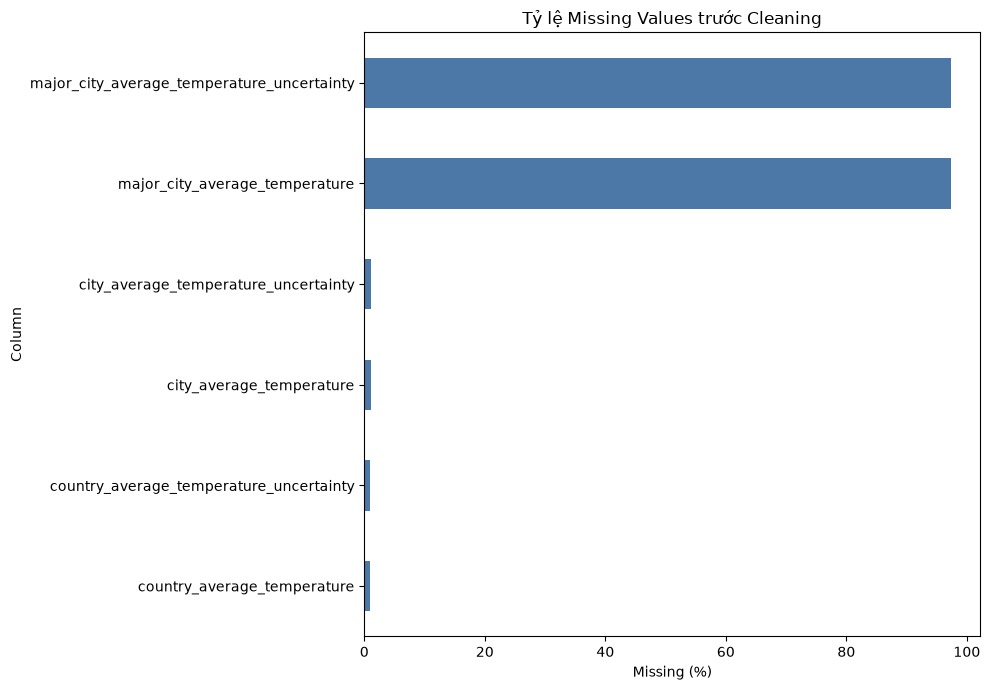

In [20]:
missing_plot_data = missing_report_before.sort_values('missing_percent')
ax = missing_plot_data.plot.barh(
    x='column', y='missing_percent', figsize=(10, 7), legend=False, color='#4C78A8'
)
ax.set_title('Tỷ lệ Missing Values trước Cleaning')
ax.set_xlabel('Missing (%)')
ax.set_ylabel('Column')
plt.tight_layout()
plt.show()

Theo data contract mới, `city_average_temperature` thiếu **58.727 dòng** và là nguyên nhân loại dòng chính. Missing rất lớn ở `major_city_*` là có chủ đích vì phần lớn thành phố không thuộc tập Major City. Các cờ `country_matched`, `global_matched` và `major_city_matched` cho biết có bản ghi enrichment hay không; chúng phân biệt đúng missing do nguồn phụ với lỗi join.


### 4.3. Kiểm tra Duplicate

Ba phép kiểm tra được tách riêng: trùng toàn bộ 27 cột nguồn và trùng khóa nghiệp vụ đầy đủ. View mới không có `source_staging_id` hoặc các khóa surrogate trong đầu ra; grain nghiệp vụ `observation_date + city_name + country_name + latitude + longitude` là quy tắc quyết định một quan sát City–month có bị nhân bản hay không.


In [21]:
duplicate_report_before = pd.DataFrame({
    'check': ['exact_full_row', 'business_key_city_month_location'],
    'duplicate_rows': [
        int(raw_df.duplicated().sum()),
        int(raw_df.duplicated(subset=BUSINESS_KEY_COLUMNS).sum()),
    ],
})
display(duplicate_report_before)


,check,duplicate_rows
0,exact_full_row,0
1,business_key_city_month_location,0


Kết quả kỳ vọng là 0 cho cả hai phép kiểm tra vì Notebook 02 đã áp dụng ràng buộc unique ở fact layer và xác nhận view không nhân bản dòng. Notebook 03 vẫn kiểm tra lại để tự bảo vệ nếu nguồn hoặc câu lệnh view thay đổi.


### 4.4. Kiểm tra giá trị không hợp lệ

Các miền hợp lệ được chọn rộng để chỉ bắt lỗi rõ ràng: vĩ độ `[-90, 90]`, kinh độ `[-180, 180]`, uncertainty không âm và nhiệt độ trung bình nằm trong `[-90°C, 60°C]`. Ngưỡng này không được dùng để loại outlier thống kê.

In [22]:
TEMPERATURE_COLUMNS = [
    'city_average_temperature', 'country_average_temperature',
    'land_average_temperature', 'land_max_temperature', 'land_min_temperature',
    'land_and_ocean_average_temperature', 'major_city_average_temperature',
]
UNCERTAINTY_COLUMNS = [
    'city_average_temperature_uncertainty',
    'country_average_temperature_uncertainty',
    'land_average_temperature_uncertainty', 'land_max_temperature_uncertainty',
    'land_min_temperature_uncertainty',
    'land_and_ocean_average_temperature_uncertainty',
    'major_city_average_temperature_uncertainty',
]

invalid_checks_before = {
    'latitude_outside_range': int((~raw_df['latitude'].between(-90, 90)).sum()),
    'longitude_outside_range': int((~raw_df['longitude'].between(-180, 180)).sum()),
    'blank_city_name': int(raw_df['city_name'].astype('string').str.strip().eq('').sum()),
    'blank_country_name': int(raw_df['country_name'].astype('string').str.strip().eq('').sum()),
    'month_outside_1_12': int((~raw_df['month'].between(1, 12)).sum()),
    'quarter_outside_1_4': int((~raw_df['quarter'].between(1, 4)).sum()),
}

for column in TEMPERATURE_COLUMNS:
    invalid_checks_before[f'{column}_outside_physical_range'] = int(
        ((raw_df[column] < -90) | (raw_df[column] > 60)).sum()
    )
for column in UNCERTAINTY_COLUMNS:
    invalid_checks_before[f'{column}_negative'] = int((raw_df[column] < 0).sum())

invalid_report_before = pd.DataFrame(
    invalid_checks_before.items(), columns=['check', 'invalid_rows']
)
display(invalid_report_before)

,check,invalid_rows
0,latitude_outside_range,0
1,longitude_outside_range,0
2,blank_city_name,0
3,blank_country_name,0
4,month_outside_1_12,0
5,quarter_outside_1_4,0
6,city_average_temperature_outside_physical_range,0
7,country_average_temperature_outside_physical_range,0
8,land_average_temperature_outside_physical_range,0
9,land_max_temperature_outside_physical_range,0


Các phép kiểm tra miền phải trả về 0 với pipeline hiện tại. Nếu xuất hiện giá trị sai, Notebook 03 sẽ loại dòng có khóa/ngày/tọa độ/nhiệt độ City không hợp lệ; uncertainty âm ở các nguồn phụ được chuyển thành missing để không làm mất một quan sát City hợp lệ.

### 4.5. Logic Validation

Logic nghiệp vụ kiểm tra sự nhất quán giữa ngày và các cột lịch, quan hệ Major City, cùng thứ tự `land_min ≤ land_average ≤ land_max`. Cột boolean `*_matched` cho biết bản ghi join có tồn tại hay không, tách biệt với trường hợp nhiệt độ enrichment có giá trị `NULL`.


In [23]:
observation_date = pd.to_datetime(raw_df['observation_date'], errors='coerce')
calendar_mismatch = (
    raw_df['year'].ne(observation_date.dt.year)
    | raw_df['month'].ne(observation_date.dt.month)
    | raw_df['quarter'].ne(observation_date.dt.quarter)
    | raw_df['decade'].ne((raw_df['year'] // 10) * 10)
)

land_order_invalid = (
    raw_df[['land_min_temperature', 'land_average_temperature', 'land_max_temperature']]
    .notna().all(axis=1)
    & (
        (raw_df['land_min_temperature'] > raw_df['land_average_temperature'])
        | (raw_df['land_average_temperature'] > raw_df['land_max_temperature'])
    )
)
major_city_logic_invalid = (
    (raw_df['is_major_city'].eq(True) & raw_df['major_city_matched'].eq(False))
    | (raw_df['is_major_city'].eq(False) & raw_df['major_city_matched'].eq(True))
)

logic_invalid_before = calendar_mismatch | major_city_logic_invalid | land_order_invalid



#### Tổng hợp kiểm tra logic

Bảng kết quả cho biết số dòng sai ở ba quy tắc: lịch phải khớp ngày quan sát, cờ thành phố lớn phải nhất quán và nhiệt độ đất phải theo thứ tự min ≤ average ≤ max.

In [24]:
logic_report_before = pd.DataFrame({
    'check': [
        'calendar_matches_observation_date',
        'major_city_flag_matches_major_city_matched',
        'land_min_average_max_order',
    ],
    'invalid_rows': [
        int(calendar_mismatch.sum()),
        int(major_city_logic_invalid.sum()),
        int(land_order_invalid.sum()),
    ],
})
display(logic_report_before)


,check,invalid_rows
0,calendar_matches_observation_date,0
1,major_city_flag_matches_major_city_matched,0
2,land_min_average_max_order,0


Kết quả kỳ vọng đều bằng 0. Đây là bằng chứng view hợp nhất giữ đúng calendar dimension và quy tắc Major City của Notebook 02. Các phép kiểm tra này được lặp lại sau cleaning để bảo đảm thao tác Python không làm sai quan hệ.

### 4.6. Tóm tắt trạng thái trước Cleaning

In [25]:
critical_missing_rows_before = int(raw_df[CRITICAL_COLUMNS].isna().any(axis=1).sum())
business_duplicates_before = int(raw_df.duplicated(BUSINESS_KEY_COLUMNS).sum())
invalid_core_mask_before = (
    ~raw_df['latitude'].between(-90, 90)
    | ~raw_df['longitude'].between(-180, 180)
    | ((raw_df['city_average_temperature'] < -90) | (raw_df['city_average_temperature'] > 60))
    | calendar_mismatch
)

quality_before = pd.DataFrame({
    'metric': [
        'rows', 'columns', 'memory_mb', 'all_missing_cells',
        'rows_with_critical_missing', 'business_duplicate_rows',
        'rows_with_invalid_core_or_calendar',
    ],
    'before': [
        len(raw_df), raw_df.shape[1], round(memory_before_mb, 2),
        int(raw_df.isna().sum().sum()), critical_missing_rows_before,
        business_duplicates_before, int(invalid_core_mask_before.sum()),
    ],
})
display(quality_before)


,metric,before
0,rows,"5,637,812.0000"
1,columns,27.0000
2,memory_mb,662.8400
3,all_missing_cells,"11,192,468.0000"
4,rows_with_critical_missing,"58,727.0000"
5,business_duplicate_rows,0.0000
6,rows_with_invalid_core_or_calendar,0.0000


Số missing cell tổng cộng lớn vì bao gồm missing có chủ đích của Major City; chỉ `rows_with_critical_missing` quyết định việc loại dòng. Bảng này được giữ làm mốc để so sánh trực tiếp với kết quả sau cleaning.

## 5. Quy tắc làm sạch

| Vấn đề | Quy tắc | Lý do |
|---|---|---|
| Sai kiểu ngày/số/boolean | Chuyển bằng `pd.to_datetime()` và `pd.to_numeric()` | Bảo đảm phép tính và so sánh đúng |
| Khoảng trắng trong City/Country | `strip()` và gộp khoảng trắng liên tiếp | Chuẩn hóa text nhưng không đổi tên riêng |
| Thiếu khóa nghiệp vụ, ngày, địa điểm, tọa độ hoặc nhiệt độ City | Xóa dòng | Không thể xác định grain hoặc target; không suy diễn nhiệt độ khí hậu |
| Thiếu cờ `*_matched` | Xóa dòng | Không thể phân biệt missing enrichment với trạng thái join |
| Thiếu uncertainty | Giữ `NaN` và thêm cờ | Không tự tạo độ tin cậy của phép đo |
| Thiếu Country/Global/Major City enrichment | Giữ `NaN` và thêm cờ available | Đây là dữ liệu phụ/structural missing từ LEFT JOIN |
| Trùng khóa nghiệp vụ City–month | Giữ dòng đầu theo thứ tự truy vấn xác định | Một City tại một tọa độ chỉ có một quan sát trong một tháng |
| Tọa độ/ngày/nhiệt độ City sai miền | Xóa dòng | Vi phạm miền dữ liệu cốt lõi |
| Uncertainty âm | Chuyển thành `NaN` | Giá trị âm không có ý nghĩa; vẫn giữ quan sát nhiệt độ |
| Outlier IQR nhưng còn hợp lệ vật lý | Giữ và tạo cờ | Cực trị khí hậu có thể là quan sát thật, không nên cắt/cap máy móc |

Các quy tắc tập trung vào bảng chính City. Notebook không làm sạch riêng State vì State không thuộc data contract mới của Notebook 02.


## 6. Thực hiện làm sạch dữ liệu

### 6.1. Chuẩn hóa data type, ngày và text

Tạo bản sao `clean_df` để không thay đổi `raw_df`. Việc chuẩn hóa thực hiện trước khi kiểm tra missing và duplicate, nhờ đó chuỗi rỗng hoặc khoảng trắng được nhận diện đúng là missing.

In [26]:
clean_df = raw_df.copy()

# Chuẩn hóa ngày.
clean_df['observation_date'] = pd.to_datetime(
    clean_df['observation_date'], errors='coerce'
)

# Chuẩn hóa tên địa điểm, không ép title-case để tránh làm sai tên riêng.
for column in ['city_name', 'country_name']:
    clean_df[column] = (
        clean_df[column]
        .astype('string')
        .str.strip()
        .str.replace(r'\s+', ' ', regex=True)
        .replace('', pd.NA)
    )

# Ép các nhóm số và boolean về dtype rõ ràng.


#### Chuẩn hóa kiểu số và boolean

Các cột lịch, nhiệt độ, tọa độ và cờ logic được ép về kiểu dữ liệu rõ ràng. Giá trị không chuyển được sẽ thành missing để được xử lý theo quy tắc ở bước sau.

In [27]:
for column in LOAD_CALENDAR_COLUMNS:
    clean_df[column] = pd.to_numeric(clean_df[column], errors='coerce').astype('Int16')
for column in LOAD_FLOAT_COLUMNS:
    clean_df[column] = pd.to_numeric(clean_df[column], errors='coerce').astype('float32')
for column in LOAD_BOOLEAN_COLUMNS:
    clean_df[column] = clean_df[column].astype('boolean')

print('Đã chuẩn hóa kiểu dữ liệu, ngày và text.')


Đã chuẩn hóa kiểu dữ liệu, ngày và text.


Các cột lịch dùng pandas nullable integer (`Int16`), còn nhiệt độ và tọa độ dùng `float32` để giảm bộ nhớ. Các cờ `is_major_city` và `*_matched` được giữ dưới dạng boolean. PostgreSQL lưu đầu ra bằng `DOUBLE PRECISION` cho các phép tính nhiệt độ/tọa độ; khóa chính của bảng sạch là khóa nghiệp vụ trực tiếp, không phải ID surrogate.


### 6.2. Xử lý Missing Values

Chỉ loại dòng thiếu dữ liệu cốt lõi. Missing ở các nguồn enrichment được giữ nguyên và biểu diễn bằng các cờ `*_available`, giúp Notebook 04 lọc đúng ngữ cảnh mà không biến missing thành một giá trị nhiệt độ giả.

In [28]:
rows_before_missing = len(clean_df)
critical_missing_mask = clean_df[CRITICAL_COLUMNS].isna().any(axis=1)
clean_df = clean_df.loc[~critical_missing_mask].copy()
missing_rows_removed = rows_before_missing - len(clean_df)

# Các cờ cho biết nguồn phụ có giá trị nhiệt độ dùng được hay không.

#### Tạo các cờ khả dụng

Các cờ này phân biệt trường hợp dữ liệu phụ không có bản ghi khớp với trường hợp có bản ghi nhưng nhiệt độ bị thiếu. Chúng được giữ lại để mô hình và người đọc hiểu nguồn dữ liệu.

In [29]:
clean_df['city_uncertainty_available'] = clean_df[
    'city_average_temperature_uncertainty'
].notna()
clean_df['country_temperature_available'] = (
    clean_df['country_matched'].eq(True)
    & clean_df['country_average_temperature'].notna()
)
clean_df['global_temperature_available'] = (
    clean_df['global_matched'].eq(True)
    & clean_df['land_average_temperature'].notna()
)
clean_df['major_city_temperature_available'] = (
    clean_df['major_city_matched'].eq(True)
    & clean_df['major_city_average_temperature'].notna()
)

print(f'Đã loại {missing_rows_removed:,} dòng thiếu dữ liệu cốt lõi.')
print(f'Còn lại {len(clean_df):,} dòng sau bước Missing Values.')


Đã loại 58,727 dòng thiếu dữ liệu cốt lõi.
Còn lại 5,579,085 dòng sau bước Missing Values.


Với data contract mới, bước này dự kiến loại **58.727 dòng** thiếu `city_average_temperature`, còn **5.579.085 dòng**. Không dùng mean/median để điền target vì nhiệt độ phụ thuộc thành phố, tháng và xu hướng lịch sử; một giá trị trung bình chung sẽ tạo dữ liệu không có thật.


### 6.3. Xử lý Duplicate và giá trị sai miền

Dữ liệu được sắp theo khóa nghiệp vụ rồi loại duplicate City–month. Tiếp theo, các dòng sai tọa độ, lịch hoặc nhiệt độ City bị loại; uncertainty âm được chuyển thành `NaN` thay vì xóa cả quan sát.


In [30]:
# Duplicate: thứ tự SELECT đã cố định theo khóa nghiệp vụ để giữ kết quả có thể tái lập.
clean_df = clean_df.sort_values(BUSINESS_KEY_COLUMNS, kind='stable')
duplicate_mask = clean_df.duplicated(subset=BUSINESS_KEY_COLUMNS, keep='first')
duplicate_rows_removed = int(duplicate_mask.sum())
clean_df = clean_df.loc[~duplicate_mask].copy()

# Xác định các dòng vi phạm miền cốt lõi.


#### Kiểm tra giá trị không hợp lệ

Sau khi bỏ duplicate, notebook kiểm tra tọa độ, nhiệt độ thành phố và sự nhất quán giữa ngày quan sát với năm/tháng/quý/thập kỷ. Các dòng sai điều kiện cốt lõi sẽ bị loại.

In [31]:
date_value = clean_df['observation_date']
calendar_invalid = (
    clean_df['year'].ne(date_value.dt.year)
    | clean_df['month'].ne(date_value.dt.month)
    | clean_df['quarter'].ne(date_value.dt.quarter)
    | clean_df['decade'].ne((clean_df['year'] // 10) * 10)
)
core_invalid_mask = (
    ~clean_df['latitude'].between(-90, 90)
    | ~clean_df['longitude'].between(-180, 180)
    | ~clean_df['city_average_temperature'].between(-90, 60)
    | calendar_invalid
)
invalid_core_rows_removed = int(core_invalid_mask.sum())
clean_df = clean_df.loc[~core_invalid_mask].copy()

# Uncertainty không thể âm: đổi giá trị sai thành missing để giữ quan sát nhiệt độ.


#### Xử lý uncertainty âm

Uncertainty âm không hợp lệ nhưng không làm mất giá trị nhiệt độ chính. Vì vậy giá trị sai được thay bằng missing thay vì xóa cả quan sát.

In [32]:
negative_uncertainty_replaced = 0
for column in UNCERTAINTY_COLUMNS:
    negative_mask = clean_df[column] < 0
    negative_uncertainty_replaced += int(negative_mask.sum())
    clean_df.loc[negative_mask, column] = np.nan

clean_df['city_uncertainty_available'] = clean_df[
    'city_average_temperature_uncertainty'
].notna()

print(f'Duplicate business key đã loại : {duplicate_rows_removed:,}')
print(f'Dòng sai miền cốt lõi đã loại : {invalid_core_rows_removed:,}')
print(f'Uncertainty âm đổi thành NaN   : {negative_uncertainty_replaced:,}')


Duplicate business key đã loại : 0
Dòng sai miền cốt lõi đã loại : 0
Uncertainty âm đổi thành NaN   : 0


Các số lượng dự kiến đều bằng 0 vì Notebook 02 đã kiểm soát grain City–month, tọa độ và calendar dimension. Việc vẫn thực hiện bước này giúp Notebook 03 an toàn khi data contract được cập nhật trong tương lai.


### 6.4. Phát hiện và xử lý Outlier

IQR được dùng để phát hiện outlier của `city_average_temperature`. Các dòng ngoài hàng rào IQR nhưng vẫn nằm trong miền vật lý được **giữ lại** và gắn cờ `city_temperature_iqr_outlier`. Không cap hoặc xóa vì cực trị mùa đông, mùa hè, vùng cực và sa mạc có thể là tín hiệu khí hậu thật.

In [33]:
target = clean_df['city_average_temperature']
q1 = float(target.quantile(0.25))
q3 = float(target.quantile(0.75))
iqr = q3 - q1
iqr_lower = q1 - 1.5 * iqr
iqr_upper = q3 + 1.5 * iqr

clean_df['city_temperature_iqr_outlier'] = (
    (target < iqr_lower) | (target > iqr_upper)
)
iqr_outliers_retained = int(clean_df['city_temperature_iqr_outlier'].sum())

# Lưu bằng chứng mỗi dòng sạch chỉ là một dòng đã chọn từ nguồn trước khi reset index.


#### Gắn cờ outlier và hoàn thiện DataFrame

Ngưỡng IQR chỉ dùng để nhận diện outlier, không xóa các dòng này vì nhiệt độ cực trị có thể mang ý nghĩa khí hậu. Sau đó text được nén sang `category` và dữ liệu được sắp theo khóa nghiệp vụ.

In [34]:
source_row_index_subset = clean_df.index.isin(raw_df.index).all()

# Chuyển text lặp lại sang category sau khi hoàn tất chuẩn hóa.
clean_df['city_name'] = clean_df['city_name'].astype('category')
clean_df['country_name'] = clean_df['country_name'].astype('category')
clean_df = clean_df.sort_values(BUSINESS_KEY_COLUMNS).reset_index(drop=True)

print(f'Ngưỡng IQR: [{iqr_lower:.3f}, {iqr_upper:.3f}] °C')
print(f'Outlier IQR được giữ lại và gắn cờ: {iqr_outliers_retained:,} dòng')



Ngưỡng IQR: [-9.440, 46.683] °C
Outlier IQR được giữ lại và gắn cờ: 100,721 dòng


#### Hiển thị kết quả outlier

In ngưỡng IQR, số dòng được gắn cờ và một mẫu gồm các giá trị nhiệt độ thấp nhất/cao nhất để kiểm tra trực quan.

In [35]:
outlier_sample = clean_df.loc[
    clean_df['city_temperature_iqr_outlier'],
    ['observation_date', 'city_name', 'country_name', 'city_average_temperature'],
].sort_values('city_average_temperature')
display(pd.concat([outlier_sample.head(5), outlier_sample.tail(5)]))


,observation_date,city_name,country_name,city_average_temperature
4286237,1979-02-01,Norilsk,Russia,-42.7040
1063955,1893-01-01,Kyzyl,Russia,-41.1010
3799673,1966-02-01,Norilsk,Russia,-39.9190
4095978,1974-01-01,Norilsk,Russia,-39.6830
4283118,1979-01-01,Norilsk,Russia,-39.4030
1739312,1911-02-01,Anshan,China,-9.4410
909383,1888-11-01,Pervouralsk,Russia,-9.4410
910296,1888-11-01,Yekaterinburg,Russia,-9.4410
909201,1888-11-01,Nizhniy Tagil,Russia,-9.4410
4356717,1981-01-01,Dandong,China,-9.4410


C:\Users\ACER\AppData\Local\Temp\ipykernel_14252\136405507.py:10: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[0].boxplot(before_plot, vert=True)
C:\Users\ACER\AppData\Local\Temp\ipykernel_14252\136405507.py:13: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(after_plot, vert=True)


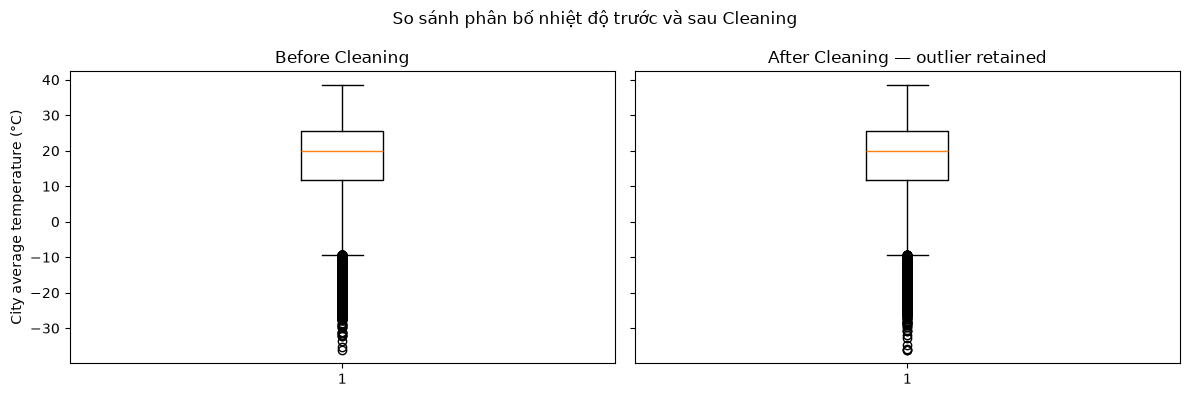

In [36]:
plot_size = min(100_000, raw_df['city_average_temperature'].notna().sum(), len(clean_df))
before_plot = raw_df['city_average_temperature'].dropna().sample(
    n=plot_size, random_state=42
)
after_plot = clean_df['city_average_temperature'].sample(
    n=plot_size, random_state=42
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
axes[0].boxplot(before_plot, vert=True)
axes[0].set_title('Before Cleaning')
axes[0].set_ylabel('City average temperature (°C)')
axes[1].boxplot(after_plot, vert=True)
axes[1].set_title('After Cleaning — outlier retained')
fig.suptitle('So sánh phân bố nhiệt độ trước và sau Cleaning')
plt.tight_layout()
plt.show()


Mẫu hai đầu phân bố cho phép kiểm tra trực tiếp các cực trị thay vì kết luận chỉ dựa trên công thức IQR. Với data contract mới, hàng rào IQR dự kiến khoảng `[-9,440; 46,683]°C` và có xấp xỉ **100.721 dòng** được gắn cờ. Vì các giá trị đã vượt qua phép kiểm tra miền vật lý `[-90, 60]°C`, chúng được giữ để Notebook 04 phân tích theo địa điểm và mùa. Hai boxplot có hình dạng gần giống nhau là kết quả có chủ đích: outlier hợp lệ được gắn cờ chứ không bị xóa hoặc cap.


### 6.5. Phân tích outliers

#### 6.5.1. Tách danh sách outlier

Lấy những dòng đã được IQR gắn cờ và tạo một bản sao tên `outlier_df`. Vì sử dụng `.copy()`, mọi cột phân tích bổ sung ở mục 6.5 đều không làm thay đổi `clean_df`.

In [37]:
OUTLIER_ANALYSIS_COLUMNS = [
    'observation_date', 'year', 'month',
    'city_name', 'country_name', 'latitude', 'longitude',
    'city_average_temperature',
    'city_average_temperature_uncertainty',
    'city_temperature_iqr_outlier',
]

outlier_df = clean_df.loc[
    clean_df['city_temperature_iqr_outlier'].eq(True),
    OUTLIER_ANALYSIS_COLUMNS,
].copy()

if len(outlier_df) != iqr_outliers_retained:
    raise RuntimeError('Số dòng trong outlier_df không khớp kết quả IQR ở mục 6.4.')

print(f'Số outlier được tách để phân tích: {len(outlier_df):,} dòng')
display(outlier_df.head())

Số outlier được tách để phân tích: 100,721 dòng


,observation_date,year,month,city_name,country_name,latitude,longitude,city_average_temperature,city_average_temperature_uncertainty,city_temperature_iqr_outlier
3,1863-01-01,1863,1,Abakan,Russia,53.8400,91.3600,-17.5320,2.2270,True
11,1863-01-01,1863,1,Acheng,China,45.8100,128.0800,-21.2850,3.6990,True
12,1863-01-01,1863,1,Achinsk,Russia,57.0500,90.0000,-16.4430,2.0350,True
52,1863-01-01,1863,1,Altay,China,47.4200,88.8200,-18.9490,2.5240,True
64,1863-01-01,1863,1,Anchorage,United States,61.8800,-151.1300,-15.0520,3.1210,True


##### Giải thích và nhận xét kết quả

Kết quả tách được **100.721 dòng**, khớp hoàn toàn với số outlier IQR đã ghi nhận ở mục 6.4 và chiếm khoảng **1,8053%** trong 5.579.085 dòng dữ liệu sạch. Năm dòng đầu đều là nhiệt độ âm vào tháng 1 tại các thành phố thuộc Nga, Trung Quốc và Hoa Kỳ; đây là dấu hiệu ban đầu cho thấy nhóm outlier có liên quan đến mùa lạnh và vị trí địa lý, thay vì xuất hiện ngẫu nhiên. `outlier_df` chỉ là bản sao phục vụ phân tích nên số dòng và giá trị trong `clean_df` không bị thay đổi.

#### 6.5.2. Thống kê outlier theo quốc gia và thành phố

Trước tiên, notebook đếm outlier theo từng địa điểm thành phố và tháng. Khi nhiều tháng cùng có tần suất cao nhất, tháng nhỏ hơn được chọn để kết quả luôn có thể tái lập.

In [38]:
CITY_LOCATION_COLUMNS = [
    'country_name', 'city_name', 'latitude', 'longitude',
]

city_month_counts = (
    outlier_df
    .groupby([*CITY_LOCATION_COLUMNS, 'month'], observed=True)
    .size()
    .rename('outlier_count_in_month')
    .reset_index()
)

most_common_outlier_month = (
    city_month_counts
    .sort_values(
        ['outlier_count_in_month', 'month'],
        ascending=[False, True],
        kind='stable',
    )
    .drop_duplicates(CITY_LOCATION_COLUMNS)
    .rename(columns={'month': 'most_common_outlier_month'})
)

Tiếp theo, mỗi địa điểm thành phố được tổng hợp theo số outlier, nhiệt độ nhỏ nhất, lớn nhất và trung bình. Bảng được sắp theo số outlier giảm dần để ưu tiên kiểm tra các địa điểm nổi bật.

In [39]:
city_outlier_summary = (
    outlier_df
    .groupby(CITY_LOCATION_COLUMNS, observed=True)
    .agg(
        outlier_count=('city_average_temperature', 'size'),
        minimum_temperature=('city_average_temperature', 'min'),
        maximum_temperature=('city_average_temperature', 'max'),
        mean_temperature=('city_average_temperature', 'mean'),
        first_outlier_date=('observation_date', 'min'),
        last_outlier_date=('observation_date', 'max'),
    )
    .reset_index()
    .merge(
        most_common_outlier_month[
            [*CITY_LOCATION_COLUMNS, 'most_common_outlier_month', 'outlier_count_in_month']
        ],
        on=CITY_LOCATION_COLUMNS,
        how='left',
        validate='one_to_one',
    )
    .sort_values(
        ['outlier_count', 'minimum_temperature'],
        ascending=[False, True],
    )
    .reset_index(drop=True)
)

display(city_outlier_summary.head(20))

,country_name,city_name,latitude,longitude,outlier_count,minimum_temperature,maximum_temperature,mean_temperature,first_outlier_date,last_outlier_date,most_common_outlier_month,outlier_count_in_month
0,Russia,Norilsk,69.9200,88.8300,1020,-42.7040,-9.4450,-23.8803,1863-01-01,2013-04-01,1,151
1,Russia,Kyzyl,52.2400,94.6000,751,-41.1010,-10.0460,-23.6742,1863-01-01,2013-02-01,1,151
2,Russia,Chita,52.2400,112.9900,737,-34.2540,-9.4820,-20.6068,1863-01-01,2013-03-01,1,151
3,China,Hailar,49.0300,120.0000,734,-34.9400,-9.4850,-20.1993,1863-01-01,2013-03-01,1,151
4,China,Yakeshi,49.0300,120.0000,734,-34.9400,-9.4850,-20.1993,1863-01-01,2013-03-01,1,151
5,Russia,Ust Ilimsk,58.6600,101.5400,727,-37.7130,-9.4580,-20.9456,1863-01-01,2013-03-01,1,151
6,Russia,Komsomolsk Na Amure,50.6300,138.1700,722,-32.7490,-9.4850,-19.1052,1863-01-01,2013-03-01,1,151
7,Russia,Ulan Ude,52.2400,107.7400,708,-32.4970,-9.4410,-18.4220,1863-01-01,2013-03-01,1,151
8,Russia,Nefteyugansk,61.8800,73.0200,701,-33.7300,-9.4610,-18.5398,1863-01-01,2013-03-01,1,151
9,Russia,Surgut,61.8800,73.0200,701,-33.7300,-9.4610,-18.5398,1863-01-01,2013-03-01,1,151


Bảng này giúp nhận biết outlier có lặp lại có hệ thống tại một thành phố hay chỉ là một quan sát đơn lẻ. Nhiều nhiệt độ thấp lặp lại ở một thành phố thuộc vùng lạnh là bằng chứng hợp lý hơn so với một giá trị cực trị xuất hiện duy nhất.

##### Giải thích và nhận xét kết quả

Các thành phố có nhiều outlier nhất tập trung chủ yếu tại Nga và Trung Quốc. Norilsk đứng đầu với **1.020** quan sát, nhiệt độ từ **−42,704°C** đến **−9,445°C**, trung bình khoảng **−23,880°C**; tháng xuất hiện nhiều nhất là tháng 1 với **151** quan sát. Kyzyl, Chita, Hailar và nhiều thành phố Siberia khác cũng có hàng trăm quan sát lạnh lặp lại trong thời gian dài từ năm 1863 đến 2013.

Việc cực trị thấp xuất hiện lặp lại theo địa điểm, tập trung ở các thành phố có vĩ độ cao và phổ biến nhất vào tháng 1 là bằng chứng cho thấy đây nhiều khả năng là đặc điểm khí hậu thật. Toàn bộ nhiệt độ lớn nhất trong nhóm dẫn đầu vẫn chỉ xấp xỉ ngưỡng dưới IQR, qua đó cũng cho thấy tập outlier hiện tại chủ yếu nằm ở phía lạnh.

#### 6.5.3. Kiểm tra theo mùa và tháng

Mùa được xác định theo bán cầu vì mùa đông và mùa hè ở hai bán cầu diễn ra vào các tháng khác nhau. Các dòng cũng được chia thành outlier thấp hoặc cao dựa trên hai ngưỡng IQR đã tính ở mục 6.4.

In [40]:
def meteorological_season(month, latitude):
    northern_season = {
        12: 'Winter', 1: 'Winter', 2: 'Winter',
        3: 'Spring', 4: 'Spring', 5: 'Spring',
        6: 'Summer', 7: 'Summer', 8: 'Summer',
        9: 'Autumn', 10: 'Autumn', 11: 'Autumn',
    }
    southern_season = {
        12: 'Summer', 1: 'Summer', 2: 'Summer',
        3: 'Autumn', 4: 'Autumn', 5: 'Autumn',
        6: 'Winter', 7: 'Winter', 8: 'Winter',
        9: 'Spring', 10: 'Spring', 11: 'Spring',
    }
    season_map = northern_season if latitude >= 0 else southern_season
    return season_map[int(month)]


outlier_df['hemisphere'] = np.where(
    outlier_df['latitude'] >= 0, 'Northern', 'Southern'
)
outlier_df['season'] = [
    meteorological_season(month, latitude)
    for month, latitude in zip(outlier_df['month'], outlier_df['latitude'])
]
outlier_df['outlier_side'] = np.where(
    outlier_df['city_average_temperature'] < iqr_lower,
    'Low',
    'High',
)

Báo cáo thứ nhất cho biết outlier phân bố theo tháng; báo cáo thứ hai kiểm tra theo mùa và bán cầu. Đây là bằng chứng về tính mùa vụ, không phải quy tắc tự động xóa dữ liệu.

In [57]:
monthly_outlier_summary = (
    outlier_df
    .groupby(['outlier_side', 'month'], observed=True)
    .size()
    .rename('outlier_count')
    .reset_index()
    .sort_values(['outlier_side', 'month'])
)
print("============= BÁO CÁO OUTLIER THEO THÁNG =============")
display(monthly_outlier_summary)

============= BÁO CÁO OUTLIER THEO THÁNG =============


,outlier_side,month,outlier_count
0,Low,1,34435
1,Low,2,28832
2,Low,3,6173
3,Low,4,163
4,Low,5,19
5,Low,10,104
6,Low,11,5616
7,Low,12,25379


In [58]:
seasonal_outlier_summary = (
    outlier_df
    .groupby(['outlier_side', 'hemisphere', 'season'], observed=True)
    .size()
    .rename('outlier_count')
    .reset_index()
    .sort_values('outlier_count', ascending=False)
)
print("============= BÁO CÁO OUTLIER THEO MÙA VÀ BẮC NAM BÁN CẦU =============")
display(seasonal_outlier_summary)

============= BÁO CÁO OUTLIER THEO MÙA VÀ BẮC NAM BÁN CẦU =============


,outlier_side,hemisphere,season,outlier_count
2,Low,Northern,Winter,88646
1,Low,Northern,Spring,6355
0,Low,Northern,Autumn,5720


##### Giải thích và nhận xét kết quả

Cả **100.721** outlier đều thuộc nhóm `Low`; không có outlier phía nhiệt độ cao. Theo tháng, số lượng lớn nhất xuất hiện vào tháng 1 (**34.435 dòng**), tháng 2 (**28.832 dòng**) và tháng 12 (**25.379 dòng**). Các tháng 6–9 không xuất hiện outlier, còn tháng 4, 5 và 10 chỉ có số lượng rất nhỏ.

Khi quy đổi theo mùa và bán cầu, **88.646 dòng (88,01%)** thuộc mùa đông Bắc bán cầu, **6.355 dòng (6,31%)** thuộc mùa xuân và **5.720 dòng (5,68%)** thuộc mùa thu. Không có outlier mùa hè hoặc Nam bán cầu. Phân bố này phù hợp rõ rệt với chu kỳ mùa lạnh, vì vậy củng cố nhận định rằng phần lớn outlier là cực trị khí hậu hợp lý chứ không phải lỗi nhập liệu ngẫu nhiên.

Các trường hợp lạnh bất thường vào mùa hè hoặc nóng bất thường vào mùa đông ở ngoài vùng nhiệt đới được đưa vào danh sách cần xem xét. Cờ này chỉ hỗ trợ điều tra; địa hình cao, dòng biển hoặc khí hậu địa phương vẫn có thể làm quan sát hợp lý.

In [42]:
outside_tropics = outlier_df['latitude'].abs() >= 23.5
outlier_df['seasonal_review_flag'] = outside_tropics & (
    (
        outlier_df['outlier_side'].eq('Low')
        & outlier_df['season'].eq('Summer')
    )
    | (
        outlier_df['outlier_side'].eq('High')
        & outlier_df['season'].eq('Winter')
    )
)

seasonal_review_sample = (
    outlier_df.loc[
        outlier_df['seasonal_review_flag'],
        [
            'observation_date', 'city_name', 'country_name',
            'latitude', 'longitude', 'season',
            'outlier_side', 'city_average_temperature',
        ],
    ]
    .sort_values('city_average_temperature')
    .head(20)
)

print(
    'Số outlier cần xem thêm do không phù hợp mùa điển hình: '
    f"{outlier_df['seasonal_review_flag'].sum():,}"
)
display(seasonal_review_sample)

Số outlier cần xem thêm do không phù hợp mùa điển hình: 0


,observation_date,city_name,country_name,latitude,longitude,season,outlier_side,city_average_temperature


##### Giải thích và nhận xét kết quả

Kết quả cho thấy **0 dòng** bị đánh dấu không phù hợp với mùa điển hình. Nói cách khác, không có trường hợp nhiệt độ cực thấp vào mùa hè hoặc nhiệt độ cực cao vào mùa đông ở ngoài vùng nhiệt đới theo quy tắc kiểm tra đã đặt ra.

Kết quả này là bằng chứng nội bộ mạnh ủng hộ việc giữ lại outlier. Tuy nhiên, cờ mùa chỉ là một phép kiểm tra sàng lọc; nó không thay thế việc đối chiếu độ cao, khí hậu địa phương hoặc nguồn khí tượng độc lập nếu cần xác minh một quan sát cụ thể.

#### 6.5.4. Kiểm tra tọa độ địa lý

Kiểm tra này xác nhận tọa độ không bị thiếu và nằm trong miền hợp lệ. Đồng thời, notebook đếm số cặp tọa độ khác nhau của mỗi `city_name + country_name` để tìm trường hợp tên địa điểm có vị trí không nhất quán.

In [43]:
outlier_df['coordinate_valid'] = (
    outlier_df['latitude'].between(-90, 90)
    & outlier_df['longitude'].between(-180, 180)
)

city_coordinate_variants = (
    outlier_df
    .groupby(['country_name', 'city_name'], observed=True)
    .agg(
        latitude_variants=('latitude', 'nunique'),
        longitude_variants=('longitude', 'nunique'),
    )
    .reset_index()
)
city_coordinate_variants['multiple_coordinates'] = (
    city_coordinate_variants['latitude_variants'].gt(1)
    | city_coordinate_variants['longitude_variants'].gt(1)
)

coordinate_audit = pd.DataFrame({
    'check': [
        'missing_coordinate_rows',
        'out_of_range_coordinate_rows',
        'city_country_with_multiple_coordinates',
    ],
    'result': [
        int(outlier_df[['latitude', 'longitude']].isna().any(axis=1).sum()),
        int((~outlier_df['coordinate_valid']).sum()),
        int(city_coordinate_variants['multiple_coordinates'].sum()),
    ],
})

display(coordinate_audit)
display(
    city_coordinate_variants.loc[
        city_coordinate_variants['multiple_coordinates']
    ].head(20)
)

,check,result
0,missing_coordinate_rows,0
1,out_of_range_coordinate_rows,0
2,city_country_with_multiple_coordinates,2


,country_name,city_name,latitude_variants,longitude_variants,multiple_coordinates
439,United States,Aurora,2,2,True
485,United States,Springfield,2,2,True


##### Giải thích và nhận xét kết quả

Không có dòng outlier nào thiếu tọa độ hoặc nằm ngoài miền vĩ độ `[-90, 90]` và kinh độ `[-180, 180]`. Vì vậy, toàn bộ **100.721 dòng** đều hợp lệ về cấu trúc tọa độ.

Có hai tổ hợp `country_name + city_name` mang nhiều tọa độ: **Aurora** và **Springfield** tại Hoa Kỳ. Đây chưa phải bằng chứng dữ liệu sai vì trong cùng một quốc gia có thể tồn tại nhiều thành phố trùng tên. Khóa nghiệp vụ của dự án đã bao gồm cả `latitude` và `longitude`, nên các địa điểm này vẫn được phân biệt. Muốn xác nhận tuyệt đối tên thành phố có khớp vị trí hay không vẫn cần đối chiếu một nguồn geocoding độc lập.

#### 6.5.5. Trực quan hóa

Biểu đồ đầu tiên hiển thị 20 quốc gia có nhiều outlier nhất. Số lượng tuyệt đối được dùng để mô tả tập dữ liệu; khi so sánh rủi ro giữa các quốc gia cần xem thêm tỷ lệ trên tổng số quan sát của từng quốc gia.

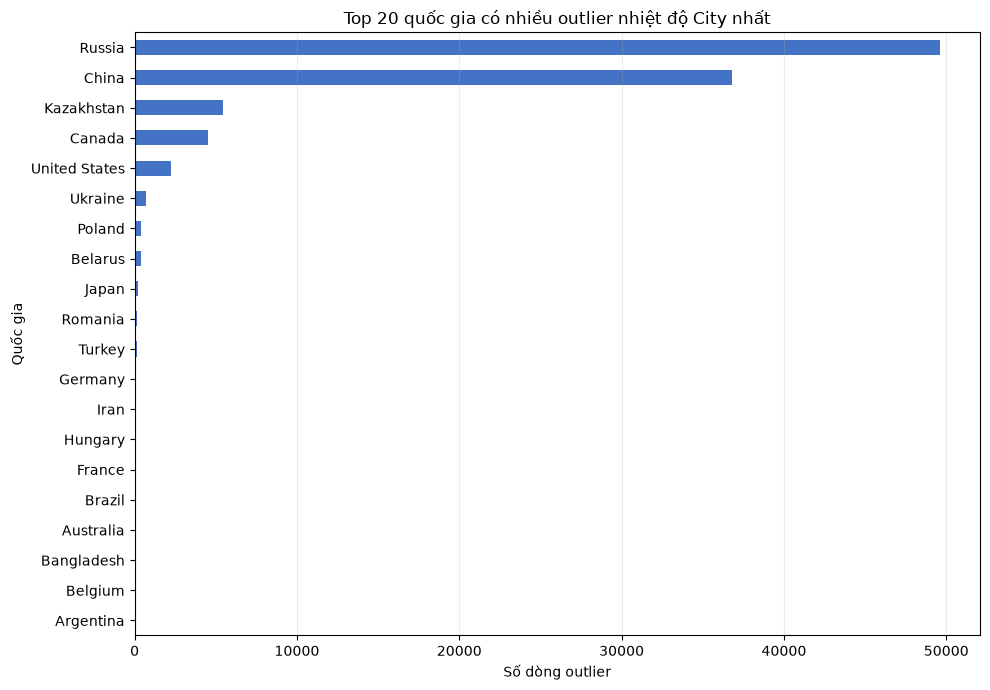

In [44]:
country_outlier_counts = (
    outlier_df['country_name']
    .value_counts()
    .head(20)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 7))
country_outlier_counts.plot(kind='barh', ax=ax, color='#4472C4')
ax.set_title('Top 20 quốc gia có nhiều outlier nhiệt độ City nhất')
ax.set_xlabel('Số dòng outlier')
ax.set_ylabel('Quốc gia')
ax.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.show()

##### Giải thích và nhận xét biểu đồ quốc gia

Biểu đồ cho thấy outlier tập trung áp đảo tại **Nga** và **Trung Quốc**, sau đó mới đến Kazakhstan, Canada và Hoa Kỳ. Đây đều là các quốc gia có nhiều khu vực thuộc khí hậu lục địa lạnh hoặc vĩ độ cao, phù hợp với việc tất cả outlier trong dữ liệu đều thuộc phía nhiệt độ thấp.

Biểu đồ sử dụng số lượng tuyệt đối nên còn chịu ảnh hưởng bởi số thành phố và số quan sát của từng quốc gia. Vì vậy, kết quả này được dùng để mô tả sự phân bố của outlier, không nên diễn giải trực tiếp thành quốc gia nào có “rủi ro” khí hậu cao hơn.

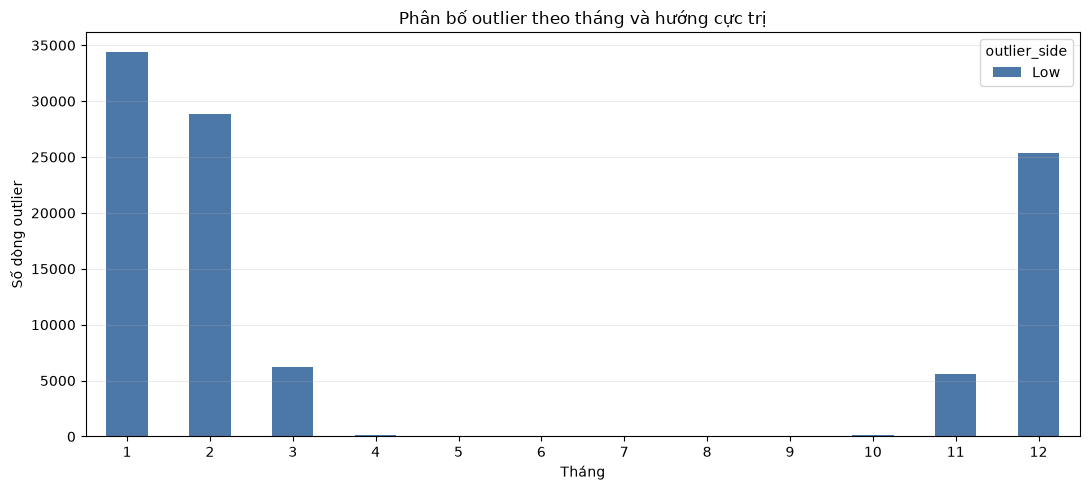

In [45]:
month_chart_data = (
    monthly_outlier_summary
    .pivot(index='month', columns='outlier_side', values='outlier_count')
    .fillna(0)
    .reindex(range(1, 13), fill_value=0)
)

ax = month_chart_data.plot(
    kind='bar',
    figsize=(11, 5),
    color={'Low': '#4C78A8', 'High': '#E45756'},
)
ax.set_title('Phân bố outlier theo tháng và hướng cực trị')
ax.set_xlabel('Tháng')
ax.set_ylabel('Số dòng outlier')
ax.tick_params(axis='x', rotation=0)
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

##### Giải thích và nhận xét biểu đồ theo tháng

Biểu đồ xác nhận outlier tập trung gần như hoàn toàn vào mùa đông: tháng 1 cao nhất, tiếp theo là tháng 2 và tháng 12. Số lượng giảm mạnh trong tháng 3 và tháng 11, rất ít vào tháng 4, 5 và 10, đồng thời bằng 0 từ tháng 6 đến tháng 9.

Chỉ có nhóm `Low` xuất hiện trên chú giải vì dữ liệu không có nhiệt độ vượt ngưỡng IQR phía trên. Mẫu phân bố theo tháng nhất quán với kết quả kiểm tra mùa và là bằng chứng quan trọng cho thấy các cực trị thấp có tính mùa vụ.

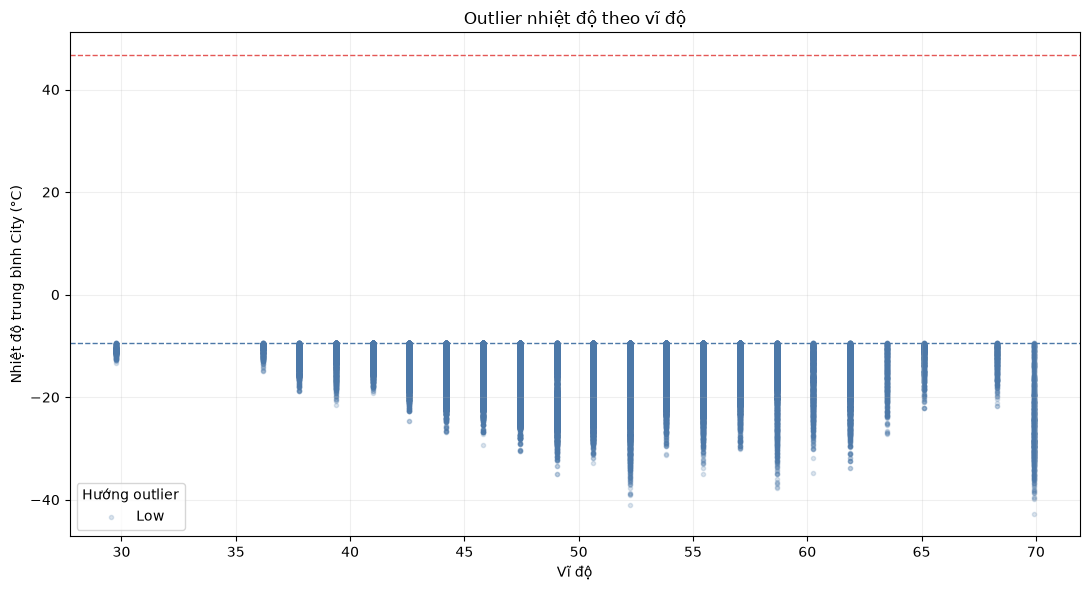

In [46]:
plot_colors = {'Low': '#4C78A8', 'High': '#E45756'}

fig, ax = plt.subplots(figsize=(11, 6))
for outlier_side, group in outlier_df.groupby('outlier_side', observed=True):
    ax.scatter(
        group['latitude'],
        group['city_average_temperature'],
        s=9,
        alpha=0.20,
        color=plot_colors[outlier_side],
        label=outlier_side,
    )

ax.axhline(iqr_lower, color='#4C78A8', linestyle='--', linewidth=1)
ax.axhline(iqr_upper, color='#E45756', linestyle='--', linewidth=1)
ax.set_title('Outlier nhiệt độ theo vĩ độ')
ax.set_xlabel('Vĩ độ')
ax.set_ylabel('Nhiệt độ trung bình City (°C)')
ax.legend(title='Hướng outlier')
ax.grid(alpha=0.20)
plt.tight_layout()
plt.show()

##### Giải thích và nhận xét biểu đồ theo vĩ độ

Các điểm outlier phân bố trong khoảng vĩ độ xấp xỉ **29° đến 70° Bắc** và đều nằm dưới ngưỡng IQR thấp khoảng **−9,440°C**. Các nhiệt độ thấp nhất tập trung rõ hơn ở vùng vĩ độ trung bình cao và vĩ độ cao; không có điểm nào vượt ngưỡng IQR phía trên.

Quan hệ giữa vĩ độ cao và nhiệt độ thấp phù hợp về mặt địa lý, nhưng biểu đồ không chứng minh quan hệ nhân quả vì nhiệt độ còn chịu ảnh hưởng của tháng, độ cao và điều kiện khí hậu địa phương. Bảng tiếp theo liệt kê các quan sát cực trị để kiểm tra chi tiết theo thành phố, ngày và tọa độ.

In [47]:
EXTREME_DISPLAY_COLUMNS = [
    'observation_date', 'city_name', 'country_name',
    'latitude', 'longitude', 'month', 'season',
    'outlier_side', 'city_average_temperature',
    'city_average_temperature_uncertainty',
    'seasonal_review_flag',
]

extreme_records = (
    pd.concat(
        [
            outlier_df.nsmallest(10, 'city_average_temperature'),
            outlier_df.nlargest(10, 'city_average_temperature'),
        ]
    )
    .drop_duplicates(BUSINESS_KEY_COLUMNS)
    [EXTREME_DISPLAY_COLUMNS]
    .sort_values('city_average_temperature')
)

display(extreme_records)

,observation_date,city_name,country_name,latitude,longitude,month,season,outlier_side,city_average_temperature,city_average_temperature_uncertainty,seasonal_review_flag
4286237,1979-02-01,Norilsk,Russia,69.9200,88.8300,2,Winter,Low,-42.7040,0.9720,False
1063955,1893-01-01,Kyzyl,Russia,52.2400,94.6000,1,Winter,Low,-41.1010,1.5000,False
3799673,1966-02-01,Norilsk,Russia,69.9200,88.8300,2,Winter,Low,-39.9190,0.9680,False
4095978,1974-01-01,Norilsk,Russia,69.9200,88.8300,1,Winter,Low,-39.6830,1.2980,False
4283118,1979-01-01,Norilsk,Russia,69.9200,88.8300,1,Winter,Low,-39.4030,0.3870,False
2036993,1919-01-01,Kyzyl,Russia,52.2400,94.6000,1,Winter,Low,-39.0380,1.5000,False
292589,1872-01-01,Kyzyl,Russia,52.2400,94.6000,1,Winter,Low,-38.9510,6.6530,False
3908393,1969-01-01,Kyzyl,Russia,52.2400,94.6000,1,Winter,Low,-38.9060,0.7610,False
3911957,1969-02-01,Norilsk,Russia,69.9200,88.8300,2,Winter,Low,-38.7840,0.9740,False
2152841,1922-02-01,Norilsk,Russia,69.9200,88.8300,2,Winter,Low,-38.7150,2.1440,False


##### Giải thích và nhận xét bảng cực trị

Mười giá trị thấp nhất đều thuộc Nga, chủ yếu tại Norilsk và Kyzyl, xuất hiện vào tháng 1 hoặc tháng 2 và không bị gắn `seasonal_review_flag`. Giá trị thấp nhất là **−42,704°C** tại Norilsk vào tháng 2 năm 1979. Các giá trị lớn nhất trong chính tập outlier đều bằng khoảng **−9,441°C**, tức chỉ thấp hơn rất ít so với hàng rào IQR dưới; chúng vẫn là outlier `Low`, không phải outlier phía nóng.

Sự nhất quán giữa nhiệt độ, mùa đông, thành phố và vĩ độ cho thấy các cực trị nổi bật có cơ sở khí hậu hợp lý. Một số quan sát lịch sử có uncertainty cao hơn, chẳng hạn Kyzyl năm 1872, nhưng uncertainty đã được giữ riêng để người phân tích đánh giá độ tin cậy thay vì xóa nhiệt độ.

#### 6.5.6. Kết luận xử lý

Outlier được phân loại thành ba trạng thái kiểm chứng nội bộ. `Plausible` nghĩa là tọa độ hợp lệ và không trái mùa điển hình; `Review` cần xem thêm do tín hiệu mùa; `Invalid coordinate` là lỗi cấu trúc rõ ràng. Phân loại này không tự động thay đổi `clean_df`.

In [48]:
outlier_df['internal_assessment'] = np.select(
    [
        ~outlier_df['coordinate_valid'],
        outlier_df['seasonal_review_flag'],
    ],
    [
        'Invalid coordinate',
        'Review seasonal context',
    ],
    default='Plausible internal evidence',
)

outlier_decision_summary = (
    outlier_df['internal_assessment']
    .value_counts(dropna=False)
    .rename_axis('assessment')
    .reset_index(name='outlier_count')
)
outlier_decision_summary['percent'] = (
    outlier_decision_summary['outlier_count'] / len(outlier_df) * 100
)

display(outlier_decision_summary)
print('Quyết định: giữ lại toàn bộ outlier hợp lệ và tiếp tục sử dụng cờ IQR.')
print('Các dòng Review chỉ được đánh dấu để phân tích sâu hơn, chưa đủ căn cứ để xóa.')

if not clean_df['city_temperature_iqr_outlier'].sum() == len(outlier_df):
    raise RuntimeError('clean_df đã bị thay đổi ngoài ý muốn trong mục 6.5.')

,assessment,outlier_count,percent
0,Plausible internal evidence,100721,100.0000


Quyết định: giữ lại toàn bộ outlier hợp lệ và tiếp tục sử dụng cờ IQR.
Các dòng Review chỉ được đánh dấu để phân tích sâu hơn, chưa đủ căn cứ để xóa.


##### Kết luận

Kết quả phân loại cho thấy **100.721/100.721 dòng (100%)** đạt trạng thái `Plausible internal evidence`; không có dòng mang tọa độ sai miền và không có dòng cần xem lại do trái mùa. Các cực trị thấp nhất như Norilsk **−42,704°C** vào tháng 2 và Kyzyl **−41,101°C** vào tháng 1 đều xuất hiện vào mùa đông, tại các thành phố có vĩ độ tương đối cao. Phần lớn outlier cũng tập trung tại Nga, Trung Quốc và các quốc gia có vùng khí hậu lạnh.

Do đó, Notebook 03 **giữ lại toàn bộ outlier** và tiếp tục đánh dấu bằng `city_temperature_iqr_outlier` thay vì xóa hoặc cắt ngưỡng. Kết luận này chứng minh tính hợp lý nội bộ dựa trên miền vật lý, mùa, địa điểm và tọa độ; nó chưa thay thế việc xác minh tuyệt đối bằng nguồn khí tượng hoặc geocoding độc lập.

## 7. Đánh giá chất lượng dữ liệu sau Cleaning

### 7.1. Kiểm tra lại Shape, Missing, Duplicate, Data Type và Logic

In [ ]:
memory_after_mb = clean_df.memory_usage(deep=True).sum() / (1024 ** 2)

date_after = clean_df['observation_date']
calendar_invalid_after = (
    clean_df['year'].ne(date_after.dt.year)
    | clean_df['month'].ne(date_after.dt.month)
    | clean_df['quarter'].ne(date_after.dt.quarter)
    | clean_df['decade'].ne((clean_df['year'] // 10) * 10)
)
land_order_invalid_after = (
    clean_df[['land_min_temperature', 'land_average_temperature', 'land_max_temperature']]
    .notna().all(axis=1)
    & (
        (clean_df['land_min_temperature'] > clean_df['land_average_temperature'])
        | (clean_df['land_average_temperature'] > clean_df['land_max_temperature'])
    )
)
major_city_logic_invalid_after = (
    (clean_df['is_major_city'].eq(True) & clean_df['major_city_matched'].eq(False))
    | (clean_df['is_major_city'].eq(False) & clean_df['major_city_matched'].eq(True))
)
logic_invalid_after = (
    calendar_invalid_after | major_city_logic_invalid_after | land_order_invalid_after
)

#### Lập báo cáo audit cuối

Báo cáo tập hợp các điều kiện cần đạt sau cleaning: không thiếu cột cốt lõi, không duplicate theo khóa nghiệp vụ, không sai miền giá trị và không sai logic. Outlier IQR vẫn được giữ lại có chủ đích.

In [50]:
after_audit = pd.DataFrame({
    'check': [
        'rows', 'columns', 'memory_mb', 'critical_missing_rows',
        'business_duplicate_rows', 'exact_full_row_duplicates',
        'invalid_coordinates', 'invalid_city_temperature',
        'negative_uncertainty_cells', 'logic_invalid_rows',
        'iqr_outliers_retained',
    ],
    'result': [
        len(clean_df), clean_df.shape[1], round(memory_after_mb, 2),
        int(clean_df[CRITICAL_COLUMNS].isna().any(axis=1).sum()),
        int(clean_df.duplicated(BUSINESS_KEY_COLUMNS).sum()),
        int(clean_df.duplicated().sum()),
        int((~clean_df['latitude'].between(-90, 90) | ~clean_df['longitude'].between(-180, 180)).sum()),
        int((~clean_df['city_average_temperature'].between(-90, 60)).sum()),
        int(sum((clean_df[column] < 0).sum() for column in UNCERTAINTY_COLUMNS)),
        int(logic_invalid_after.sum()),
        iqr_outliers_retained,
    ],
})
print("============= BÁO CÁO SAU KHI CLEANING =============")
display(after_audit)


============= BÁO CÁO SAU KHI CLEANING =============


,check,result
0,rows,"5,579,085.0000"
1,columns,32.0000
2,memory_mb,548.1400
3,critical_missing_rows,0.0000
4,business_duplicate_rows,0.0000
5,exact_full_row_duplicates,0.0000
6,invalid_coordinates,0.0000
7,invalid_city_temperature,0.0000
8,negative_uncertainty_cells,0.0000
9,logic_invalid_rows,0.0000


In [51]:
dtype_report_after = pd.DataFrame({
    'column': clean_df.columns,
    'dtype_after': clean_df.dtypes.astype(str).values,
})
print("============= BÁO CÁO DTYPE SAU KHI CLEANING =============")
display(dtype_report_after)

============= BÁO CÁO DTYPE SAU KHI CLEANING =============


,column,dtype_after
0,observation_date,datetime64[s]
1,year,Int16
2,month,Int16
3,quarter,Int16
4,decade,Int16
5,city_name,category
6,country_name,category
7,latitude,float32
8,longitude,float32
9,is_major_city,boolean


In [52]:
missing_after = clean_df.isna().sum()
missing_report_after = pd.DataFrame({
    'column': clean_df.columns,
    'missing_count': missing_after.values,
    'missing_percent': missing_after.values / len(clean_df) * 100,
})
print("============= BÁO CÁO MISSING SAU KHI CLEANING =============")
display(missing_report_after.query('missing_count > 0').sort_values(
    'missing_percent', ascending=False
))

required_zero_checks = after_audit.loc[
    after_audit['check'].isin([
        'critical_missing_rows', 'business_duplicate_rows', 'duplicate_lineage_rows',
        'invalid_coordinates', 'invalid_city_temperature',
        'negative_uncertainty_cells', 'logic_invalid_rows',
    ]), 'result'
]
if not (required_zero_checks == 0).all():
    raise RuntimeError('Dữ liệu sau cleaning vẫn còn lỗi bắt buộc. Xem after_audit.')

print('Post-cleaning audit: PASS')

============= BÁO CÁO MISSING SAU KHI CLEANING =============


,column,missing_count,missing_percent
26,major_city_average_temperature_uncertainty,5427792,97.2882
25,major_city_average_temperature,5427792,97.2882
14,country_average_temperature_uncertainty,6135,0.1100
13,country_average_temperature,6135,0.1100


Post-cleaning audit: PASS


Audit chỉ yêu cầu bằng 0 đối với critical missing, duplicate, giá trị sai miền và lỗi logic. Outlier IQR không phải lỗi; số lượng này được báo cáo riêng để chứng minh nhóm đã phát hiện và chủ động giữ lại. Khóa nghiệp vụ trực tiếp được dùng thay cho lineage ID đã không còn trong view bàn giao.


### 7.2. Bảng so sánh Before–After

In [53]:
before_after_summary = pd.DataFrame({
    'metric': [
        'rows', 'columns', 'memory_mb', 'all_missing_cells',
        'critical_missing_rows', 'business_duplicate_rows',
        'invalid_core_or_logic_rows', 'iqr_outliers',
    ],
    'before': [
        len(raw_df), raw_df.shape[1], round(memory_before_mb, 2),
        int(raw_df.isna().sum().sum()), critical_missing_rows_before,
        business_duplicates_before,
        int((invalid_core_mask_before | logic_invalid_before).sum()),
        'not flagged',
    ],
    'after': [
        len(clean_df), clean_df.shape[1], round(memory_after_mb, 2),
        int(clean_df.isna().sum().sum()),
        int(clean_df[CRITICAL_COLUMNS].isna().any(axis=1).sum()),
        int(clean_df.duplicated(BUSINESS_KEY_COLUMNS).sum()),
        int(logic_invalid_after.sum()), iqr_outliers_retained,
    ],
})
display(before_after_summary)

rows_removed_total = len(raw_df) - len(clean_df)
print(f'Tổng số dòng đã loại: {rows_removed_total:,}')
print(f'Tỷ lệ dòng đã loại : {rows_removed_total / len(raw_df) * 100:.4f}%')


,metric,before,after
0,rows,5637812,"5,579,085.0000"
1,columns,27,32.0000
2,memory_mb,662.8400,548.1400
3,all_missing_cells,11192468,"10,867,854.0000"
4,critical_missing_rows,58727,0.0000
5,business_duplicate_rows,0,0.0000
6,invalid_core_or_logic_rows,0,0.0000
7,iqr_outliers,not flagged,"100,721.0000"


Tổng số dòng đã loại: 58,727
Tỷ lệ dòng đã loại : 1.0417%


Row count giảm chủ yếu do target City bị thiếu. Với data contract mới, dự kiến loại **58.727 / 5.637.812 dòng** (khoảng **1,0417%**) và còn **5.579.085 dòng** nếu không phát sinh duplicate hoặc giá trị sai miền. Tổng missing cell sau cleaning có thể vẫn lớn vì các cột Major City và Country/Global enrichment được giữ `NaN` theo đúng ý nghĩa; đây không phải bằng chứng cleaning thất bại. Các cờ available giúp bước EDA sử dụng chúng an toàn.


### 7.3. Kiểm tra lineage và grain sau Cleaning

In [54]:
grain_check = pd.DataFrame({
    'check': [
        'business_key_not_null',
        'business_key_unique',
        'rows_are_selected_from_source',
        'date_range_preserved',
    ],
    'status': [
        clean_df[BUSINESS_KEY_COLUMNS].notna().all(axis=None),
        not clean_df.duplicated(BUSINESS_KEY_COLUMNS).any(),
        source_row_index_subset,
        clean_df['observation_date'].between(EXPECTED_MIN_DATE, EXPECTED_MAX_DATE).all(),
    ],
})
display(grain_check)

if not grain_check['status'].all():
    raise RuntimeError('Khóa nghiệp vụ hoặc grain bị vi phạm sau cleaning.')
print('Khóa nghiệp vụ và grain: PASS')


,check,status
0,business_key_not_null,True
1,business_key_unique,True
2,rows_are_selected_from_source,True
3,date_range_preserved,True


Khóa nghiệp vụ và grain: PASS


Mỗi dòng sạch vẫn là một dòng được chọn từ dữ liệu nguồn; Notebook 03 chỉ loại dòng theo quy tắc đã ghi, không tạo quan sát mới và không làm thay đổi grain City–month. Vì view bàn giao không còn các cột ID, tổ hợp `observation_date + city_name + country_name + latitude + longitude` được dùng để kiểm tra tính duy nhất của grain.


## 8. Lưu dữ liệu đã làm sạch

### 8.1. Lưu file trong `data/processed/`

File CSV là sản phẩm có thể tái tạo từ PostgreSQL và notebook này. Không ghi đè dữ liệu trong `data/raw/`. Do file có hàng triệu dòng, thao tác có thể mất vài phút.

In [55]:
OUTPUT_FLAG_COLUMNS = [
    'city_uncertainty_available', 'country_temperature_available',
    'global_temperature_available', 'major_city_temperature_available',
    'city_temperature_iqr_outlier',
]
EXPECTED_OUTPUT_COLUMNS = SOURCE_COLUMNS + OUTPUT_FLAG_COLUMNS

if list(clean_df.columns) != EXPECTED_OUTPUT_COLUMNS:
    raise RuntimeError('Thứ tự cột output không đúng data contract của Notebook 03.')

clean_df.to_csv(
    CLEANED_CSV_PATH,
    index=False,
    encoding='utf-8',
    date_format='%Y-%m-%d',
)

csv_size_mb = CLEANED_CSV_PATH.stat().st_size / (1024 ** 2)
print('Đã lưu:', CLEANED_CSV_PATH)
print(f'Kích thước file: {csv_size_mb:,.2f} MB')

Đã lưu: E:\FPT\HocKy3\PROJECT_1\PROJECT\Global-Surface-Temperature-Analysis\data\processed\cleaned_city_temperature.csv
Kích thước file: 968.42 MB


File phải tồn tại và có kích thước lớn hơn 0. `data/processed/` là dữ liệu sinh ra từ pipeline, vì vậy nên được tái tạo bằng notebook thay vì chỉnh sửa thủ công.

### 8.2. Import file CSV vào PostgreSQL bằng pgAdmin 4

Sau khi Mục 8.1 tạo thành công `cleaned_city_temperature.csv`, việc tạo bảng và import được thực hiện trực tiếp trong pgAdmin 4.

#### 8.2.1. Tạo bảng đích trong Query Tool


Trong pgAdmin 4, chọn **Servers → PostgreSQL → Databases → climate_db**, nhấp phải `climate_db` và mở **Query Tool**. Chạy toàn bộ khối SQL dưới đây:


In [ ]:
DROP TABLE IF EXISTS public.cleaned_city_temperature;

CREATE TABLE public.cleaned_city_temperature (
    observation_date DATE NOT NULL,
    year SMALLINT NOT NULL,
    month SMALLINT NOT NULL CHECK (month BETWEEN 1 AND 12),
    quarter SMALLINT NOT NULL CHECK (quarter BETWEEN 1 AND 4),
    decade SMALLINT NOT NULL,
    city_name TEXT NOT NULL,
    country_name TEXT NOT NULL,
    latitude DOUBLE PRECISION NOT NULL CHECK (latitude BETWEEN -90 AND 90),
    longitude DOUBLE PRECISION NOT NULL CHECK (longitude BETWEEN -180 AND 180),
    is_major_city BOOLEAN NOT NULL,
    city_average_temperature DOUBLE PRECISION NOT NULL CHECK (city_average_temperature BETWEEN -90 AND 60),
    city_average_temperature_uncertainty DOUBLE PRECISION,
    country_matched BOOLEAN NOT NULL,
    country_average_temperature DOUBLE PRECISION,
    country_average_temperature_uncertainty DOUBLE PRECISION,
    global_matched BOOLEAN NOT NULL,
    land_average_temperature DOUBLE PRECISION,
    land_average_temperature_uncertainty DOUBLE PRECISION,
    land_max_temperature DOUBLE PRECISION,
    land_max_temperature_uncertainty DOUBLE PRECISION,
    land_min_temperature DOUBLE PRECISION,
    land_min_temperature_uncertainty DOUBLE PRECISION,
    land_and_ocean_average_temperature DOUBLE PRECISION,
    land_and_ocean_average_temperature_uncertainty DOUBLE PRECISION,
    major_city_matched BOOLEAN NOT NULL,
    major_city_average_temperature DOUBLE PRECISION,
    major_city_average_temperature_uncertainty DOUBLE PRECISION,
    city_uncertainty_available BOOLEAN NOT NULL,
    country_temperature_available BOOLEAN NOT NULL,
    global_temperature_available BOOLEAN NOT NULL,
    major_city_temperature_available BOOLEAN NOT NULL,
    city_temperature_iqr_outlier BOOLEAN NOT NULL,
    PRIMARY KEY (observation_date, city_name, country_name, latitude, longitude),
    CHECK (NOT is_major_city OR major_city_matched),
    CHECK (is_major_city OR NOT major_city_matched)
);

COMMENT ON TABLE public.cleaned_city_temperature IS
    'Cleaned City-month dataset produced by Notebook 03 using direct business values';


Sau khi chạy thành công, pgAdmin hiển thị `CREATE TABLE` và bảng `cleaned_city_temperature` xuất hiện trong **Schemas → public → Tables**. DDL thay thế bảng output cũ để có thể chạy lại pipeline; thao tác này chỉ tác động bảng sạch, không tác động staging, dimension, fact hoặc view của Notebook 02. Bảng mới có **32 cột**, dùng khóa chính nghiệp vụ gồm ngày, tên City/Country và tọa độ; các cột enrichment vẫn cho phép `NULL`.


#### 8.2.2. Import CSV bằng cửa sổ Import/Export Data

Thực hiện lần lượt trong pgAdmin 4:

1. Trong cây đối tượng, nhấp phải **public.cleaned_city_temperature** → **Import/Export Data…**.
2. Chọn chế độ **Import**.
3. Tại **Filename**, chọn file `data/processed/cleaned_city_temperature.csv` vừa tạo ở Mục 8.1.
4. Thiết lập **Format = csv**, **Encoding = UTF8**.
5. Trong **Options**, đặt **Header = Yes**, **Delimiter = ,**, **Quote = "**, **Escape = "** và để **NULL String** trống.
6. Trong tab **Columns**, giữ đúng toàn bộ **32 cột** theo thứ tự của file CSV.
7. Nhấn **OK** và chờ thông báo hoàn tất. Với khoảng **5,58 triệu dòng**, quá trình import có thể mất vài phút.

Nếu pgAdmin báo `Permission denied`, hãy bảo đảm PostgreSQL đang chạy cục bộ và tài khoản dịch vụ PostgreSQL có quyền đọc file. Có thể sao chép file tới một thư mục đơn giản như `D:\postgresql_import\` rồi chọn lại file.

#### 8.2.3. Tạo index và cập nhật thống kê

In [ ]:
CREATE INDEX idx_cleaned_city_observation_date
    ON public.cleaned_city_temperature (observation_date);

CREATE INDEX idx_cleaned_city_country_date
    ON public.cleaned_city_temperature (country_name, observation_date);

ANALYZE public.cleaned_city_temperature;

Hai index hỗ trợ EDA theo thời gian và theo quốc gia–thời gian. View mới không dùng `country_id`, nên index tổng hợp dùng trực tiếp `(country_name, observation_date)`. `ANALYZE` không thay đổi dữ liệu; lệnh cập nhật thống kê để PostgreSQL planner lựa chọn kế hoạch truy vấn phù hợp.


### 8.3. Kiểm tra bảng PostgreSQL sau khi import

Mở Query Tool của `climate_db` và chạy truy vấn dưới đây. Số dòng kỳ vọng **5.579.085** được suy ra từ data contract mới: 5.637.812 dòng nguồn trừ 58.727 dòng thiếu target City. Nếu các bước cleaning sau này phát hiện thêm duplicate hoặc giá trị sai miền, thay giá trị này bằng `len(clean_df)` đã in trong notebook.

In [ ]:
WITH audit AS (
    SELECT
        COUNT(*)::BIGINT AS database_rows,
        MIN(observation_date) AS min_date,
        MAX(observation_date) AS max_date,
        COUNT(*) FILTER (
            WHERE city_average_temperature IS NULL
        )::BIGINT AS missing_target_rows,
        COUNT(*) FILTER (
            WHERE latitude NOT BETWEEN -90 AND 90
               OR longitude NOT BETWEEN -180 AND 180
        )::BIGINT AS invalid_coordinate_rows,
        COUNT(*) - COUNT(DISTINCT (
            observation_date, city_name, country_name, latitude, longitude
        )) AS duplicate_business_key_rows,
        COUNT(*) FILTER (
            WHERE (is_major_city AND NOT major_city_matched)
               OR (NOT is_major_city AND major_city_matched)
        )::BIGINT AS invalid_major_city_logic_rows,
        COUNT(*) FILTER (
            WHERE city_temperature_iqr_outlier
        )::BIGINT AS retained_outlier_rows
    FROM public.cleaned_city_temperature
)
SELECT
    audit.*,
    5579085::BIGINT AS expected_rows,
    CASE
        WHEN database_rows = 5579085
         AND missing_target_rows = 0
         AND invalid_coordinate_rows = 0
         AND duplicate_business_key_rows = 0
         AND invalid_major_city_logic_rows = 0
        THEN 'PASS'
        ELSE 'FAIL'
    END AS status
FROM audit;

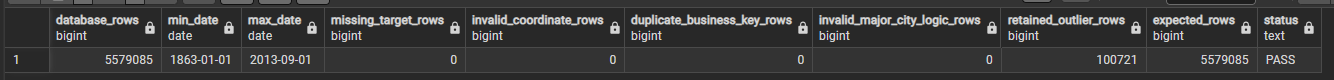

Kết quả đúng phải có `database_rows = expected_rows = 5.579.085`, `missing_target_rows = 0`, `duplicate_business_key_rows = 0`, `invalid_coordinate_rows = 0`, `invalid_major_city_logic_rows = 0` và `status = PASS`. `retained_outlier_rows` dự kiến khoảng **100.721**; đây là outlier khí hậu hợp lệ được chủ động giữ lại nên không làm validation thất bại.


## 9. Kết luận và bàn giao cho Notebook 04

Notebook 03 trả lời bốn câu hỏi cốt lõi:

1. **Dữ liệu gặp vấn đề gì?** View City có missing target, missing enrichment có chủ đích, và cần kiểm tra lại duplicate, kiểu dữ liệu, miền giá trị, logic lịch và outlier.
2. **Đã xử lý như thế nào?** Dòng thiếu dữ liệu cốt lõi bị loại; enrichment missing được giữ và thêm cờ; duplicate theo khóa nghiệp vụ bị loại có quy tắc; giá trị sai miền được xử lý; outlier khí hậu hợp lệ được giữ và gắn cờ.
3. **Chất lượng thay đổi ra sao?** Bảng Before–After báo row count, missing, duplicate, invalid, bộ nhớ và outlier. Audit sau cleaning yêu cầu critical missing, duplicate, invalid và lỗi logic đều bằng 0.
4. **Dữ liệu đã sẵn sàng chưa?** Khi truy vấn kiểm tra tại Mục 8.3 trong pgAdmin 4 trả `PASS`, `public.cleaned_city_temperature` là nguồn chính cho Notebook 04; file `data/processed/cleaned_city_temperature.csv` là bản xuất có thể tái tạo.

Notebook 04 cần đọc bảng `public.cleaned_city_temperature`, sử dụng `city_average_temperature` làm biến nhiệt độ City chính, tôn trọng các cờ `*_available` và `*_matched`, và phân tích riêng các dòng `city_temperature_iqr_outlier` thay vì tự động loại bỏ.

## 10. Checklist hoàn thành Notebook 03

- [x] Đọc dữ liệu từ PostgreSQL bằng `pd.read_sql_query()`; không đọc lại CSV raw.
- [x] Kiểm tra Shape, dtype, memory usage và dữ liệu mẫu.
- [x] Thống kê missing count và missing percentage theo ý nghĩa.
- [x] Kiểm tra exact duplicate và duplicate theo khóa nghiệp vụ City–month.
- [x] Chuẩn hóa Date, Numeric, Category/Text và Boolean.
- [x] Kiểm tra invalid values và logic nghiệp vụ.
- [x] Phát hiện outlier bằng IQR và giải thích quyết định giữ lại.
- [x] So sánh chất lượng Before–After.
- [x] Bảo toàn grain `observation_date + city_name + country_name + latitude + longitude`.
- [x] Lưu CSV trong `data/processed/`, sau đó tạo và import bảng sạch vào PostgreSQL bằng pgAdmin 4.
- [x] Xác nhận data contract bàn giao cho Notebook 04.